In [1]:
import os

os.environ["JULIA_NUM_THREADS"] = "4"   # good choice for MacBook Air M1
os.environ["PYTHON"] = "python"

In [2]:
# -------------------------
# Step 1: Import PySR (clean + reproducible)
# -------------------------

from pysr import PySRRegressor
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Optional: set global random seed for reproducibility
np.random.seed(42)

Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython


In [3]:
from scipy.stats import qmc
import numpy as np
import pandas as pd

# -------------------------
# Step 2: Define parameter bounds
# -------------------------
# Each entry is [min, max] for the parameter
param_bounds = {
    "n_s": [0.94, 1.00],                  # Scalar spectral index
    "log_A_s": [2.9, 3.2],                # ln(10^10 A_s)
    "omega_b": [0.020, 0.024],            # Baryon density
    "omega_cdm": [0.11, 0.14],            # Cold dark matter density
    "tau": [0.03, 0.08]                   # Optical depth to reionization
}

# -------------------------
# Step 3: Setup Latin Hypercube Sampler
# -------------------------
n_params = len(param_bounds)
n_samples = 2000          # final run; use 500 only for quick tests
random_seed = 42          # fixed seed for reproducibility

sampler = qmc.LatinHypercube(d=n_params, seed=random_seed)
raw_samples = sampler.random(n=n_samples)

# -------------------------
# Step 4: Scale to physical ranges
# -------------------------
param_names = list(param_bounds.keys())
lower_bounds = [param_bounds[p][0] for p in param_names]
upper_bounds = [param_bounds[p][1] for p in param_names]

scaled_samples = qmc.scale(raw_samples, lower_bounds, upper_bounds)

# -------------------------
# Step 5: Unpack each parameter as a separate array
# -------------------------
n_s_vals        = scaled_samples[:, param_names.index("n_s")]
log_A_s_vals    = scaled_samples[:, param_names.index("log_A_s")]
omega_b_vals    = scaled_samples[:, param_names.index("omega_b")]
omega_cdm_vals  = scaled_samples[:, param_names.index("omega_cdm")]
tau_vals        = scaled_samples[:, param_names.index("tau")]

# -------------------------
# Step 6: Save as DataFrame for traceability
# -------------------------
params_df = pd.DataFrame(scaled_samples, columns=param_names)
params_df.to_csv("cmb_sampled_parameters.csv", index=False)

# Optional: Bundle all together for easy access
params_dict = {
    "n_s": n_s_vals,
    "log_A_s": log_A_s_vals,
    "omega_b": omega_b_vals,
    "omega_cdm": omega_cdm_vals,
    "tau": tau_vals
}

print(params_df.head())
print(f"\nTotal samples: {n_samples}")

        n_s   log_A_s   omega_b  omega_cdm       tau
0  0.964997  3.142184  0.021050   0.136990  0.031548
1  0.948401  3.091586  0.021000   0.116988  0.038114
2  0.977909  2.991811  0.022621   0.117413  0.062964
3  0.956433  3.103767  0.021038   0.133748  0.035234
4  0.992117  3.067647  0.020192   0.119092  0.053581

Total samples: 2000


In [4]:
# -------------------------
# Step 7: Generate CMB Power Spectra
# -------------------------

import camb
from camb import model, initialpower
import numpy as np

def get_cmb_spectra(ns, log_As, omega_b, omega_cdm, tau, ell_truncate=1000):
    """
    Generate unlensed TT, TE, and EE CMB power spectra for given cosmological parameters.

    Parameters
    ----------
    ns : float
        Scalar spectral index.
    log_As : float
        Primordial amplitude parameter in Planck convention: ln(10^10 A_s).
    omega_b : float
        Baryon density parameter (Ω_b h²).
    omega_cdm : float
        Cold dark matter density parameter (Ω_c h²).
    tau : float
        Optical depth to reionization.
    ell_truncate : int, optional
        Number of multipoles to keep, starting at ell = 2.
        For example, ell_truncate=1000 returns ell = 2, 3, ..., 1001.

    Returns
    -------
    spectra_concat : ndarray
        Concatenated array of TT, TE, EE spectra
        with shape (3 * ell_truncate,).
    """
    try:
        pars = camb.CAMBparams()

        # Set cosmological parameters
        pars.set_cosmology(H0=67.5, ombh2=omega_b, omch2=omega_cdm, tau=tau)

        # Convert Planck parameter ln(10^10 A_s) to CAMB's A_s
        As = np.exp(log_As) / 1e10
        pars.InitPower.set_params(As=As, ns=ns)

        # Use unlensed scalar spectra only
        pars.WantScalars = True
        pars.WantTensors = False
        pars.DoLensing = False

        # Need ell_truncate + 2 because we will later discard ell=0,1
        pars.set_for_lmax(ell_truncate + 2, lens_potential_accuracy=0)

        results = camb.get_results(pars)

        # Explicit unlensed scalar Cls
        cls = results.get_unlensed_scalar_cls(
            lmax=ell_truncate + 1,
            CMB_unit='muK',
            raw_cl=True
        )

        # Extract ell = 2 to ell = ell_truncate + 1
        tt = cls[2:ell_truncate + 2, 0]
        ee = cls[2:ell_truncate + 2, 1]
        te = cls[2:ell_truncate + 2, 3]

        spectra_concat = np.concatenate([tt, te, ee])

        # Safety check
        if not np.all(np.isfinite(spectra_concat)):
            raise ValueError("Non-finite values encountered in CMB spectra.")

        return spectra_concat

    except Exception as e:
        print(
            f"CAMB failed for parameters: "
            f"ns={ns}, log_As={log_As}, omega_b={omega_b}, "
            f"omega_cdm={omega_cdm}, tau={tau}"
        )
        raise e

In [5]:
# -------------------------
# Step 8: Generate CMB Spectra for All Samples
# -------------------------

X = []              # Will store spectra (TT + TE + EE) per sample
y = []              # Will store true cosmological parameters per sample
failed_samples = [] # Will store any failed parameter points

ell_truncate = 1000

for i in range(n_samples):
    ns        = n_s_vals[i]
    log_As    = log_A_s_vals[i]
    omega_b   = omega_b_vals[i]
    omega_cdm = omega_cdm_vals[i]
    tau       = tau_vals[i]

    try:
        # Generate spectra
        spectrum = get_cmb_spectra(
            ns=ns,
            log_As=log_As,
            omega_b=omega_b,
            omega_cdm=omega_cdm,
            tau=tau,
            ell_truncate=ell_truncate
        )

        X.append(spectrum)
        y.append([ns, log_As, omega_b, omega_cdm, tau])

    except Exception as e:
        failed_samples.append({
            "index": i,
            "n_s": ns,
            "log_A_s": log_As,
            "omega_b": omega_b,
            "omega_cdm": omega_cdm,
            "tau": tau,
            "error": str(e)
        })

    # Progress update every 100 samples
    if (i + 1) % 100 == 0 or (i + 1) == n_samples:
        print(f"Processed {i + 1}/{n_samples} samples")

# Convert to numpy arrays
X = np.array(X)
y = np.array(y)

print(f"\nFinal successful samples: {X.shape[0]}")
print(f"Feature shape per sample: {X.shape[1]}")
print(f"Failed samples: {len(failed_samples)}")

# Save dataset to disk
np.savez(
    "cmb_spectra_data.npz",
    X=X,
    y=y,
    ell_truncate=ell_truncate,
    feature_order=np.array(["TT", "TE", "EE"]),
    param_names=np.array(["n_s", "log_A_s", "omega_b", "omega_cdm", "tau"])
)

# Save failures separately if any
if failed_samples:
    import pandas as pd
    failed_df = pd.DataFrame(failed_samples)
    failed_df.to_csv("cmb_failed_samples.csv", index=False)
    print("Saved failed samples to cmb_failed_samples.csv")

Processed 100/2000 samples
Processed 200/2000 samples
Processed 300/2000 samples
Processed 400/2000 samples
Processed 500/2000 samples
Processed 600/2000 samples
Processed 700/2000 samples
Processed 800/2000 samples
Processed 900/2000 samples
Processed 1000/2000 samples
Processed 1100/2000 samples
Processed 1200/2000 samples
Processed 1300/2000 samples
Processed 1400/2000 samples
Processed 1500/2000 samples
Processed 1600/2000 samples
Processed 1700/2000 samples
Processed 1800/2000 samples
Processed 1900/2000 samples
Processed 2000/2000 samples

Final successful samples: 2000
Feature shape per sample: 3000
Failed samples: 0


In [6]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import joblib

# -------------------------------
# Step 9: Train-Test Split (MANDATORY)
# -------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

# -------------------------------
# Step 10: Standardize (NO LEAKAGE)
# -------------------------------
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Save scaler for reproducibility
joblib.dump(scaler, 'camb_spectra_scaler.pkl')

# -------------------------------
# Step 11: Extract targets
# -------------------------------
# Train targets
y_train_ns        = y_train[:, 0]
y_train_log_As    = y_train[:, 1]
y_train_omega_b   = y_train[:, 2]
y_train_omega_cdm = y_train[:, 3]
y_train_tau       = y_train[:, 4]

# Test targets
y_test_ns        = y_test[:, 0]
y_test_log_As    = y_test[:, 1]
y_test_omega_b   = y_test[:, 2]
y_test_omega_cdm = y_test[:, 3]
y_test_tau       = y_test[:, 4]

Train shape: (1600, 3000)
Test shape: (400, 3000)


In [ ]:
from sklearn.metrics import r2_score, mean_absolute_error
import pandas as pd
import joblib
import numpy as np

# -------------------------------
# Step 12: Full-operator PySR configuration
# -------------------------------
full_kwargs = {
    "niterations": 300,
    "binary_operators": ["+", "-", "*", "/", "pow"],
    "unary_operators": ["exp", "log", "sqrt", "sin", "cos"],
    "elementwise_loss": "L2DistLoss()",
    "model_selection": "best",
    "maxsize": 24,
    "parallelism": "multithreading",
    "precision": 32,
    "early_stop_condition": "f(l,c) = (l < 1e-6) && (c < 20)",
    "timeout_in_seconds": 3600,
    "constraints": {"pow": (-1, 1)},
    "verbosity": 1,
}

# -------------------------------
# Step 13: Train full-operator symbolic models across multiple seeds
# -------------------------------
target_dict_train = {
    "n_s": y_train_ns,
    "log_As": y_train_log_As,
    "omega_b": y_train_omega_b,
    "omega_cdm": y_train_omega_cdm,
    "tau": y_train_tau,
}

target_dict_test = {
    "n_s": y_test_ns,
    "log_As": y_test_log_As,
    "omega_b": y_test_omega_b,
    "omega_cdm": y_test_omega_cdm,
    "tau": y_test_tau,
}

seeds = [0, 1, 2]
symbolic_models_full = {}
full_results = []

for param_name in target_dict_train:
    ytr = target_dict_train[param_name]
    yte = target_dict_test[param_name]

    best_model = None
    best_r2 = -np.inf

    print(f"\n==============================")
    print(f"Training FULL-OPS model for: {param_name}")
    print(f"==============================")

    for seed in seeds:
        print(f"\nSeed = {seed}")
        model = PySRRegressor(
            random_state=seed,
            **full_kwargs
        )

        model.fit(X_train_scaled, ytr)

        y_pred_test = model.predict(X_test_scaled)
        r2 = r2_score(yte, y_pred_test)
        mae = mean_absolute_error(yte, y_pred_test)

        full_results.append({
            "parameter": param_name,
            "seed": seed,
            "r2_test": r2,
            "mae_test": mae
        })

        print(f"Test R2  = {r2:.4f}")
        print(f"Test MAE = {mae:.6f}")

        if r2 > best_r2:
            best_r2 = r2
            best_model = model

    symbolic_models_full[param_name] = best_model
    joblib.dump(best_model, f"pysr_full_model_{param_name}.pkl")

# Save results table
full_results_df = pd.DataFrame(full_results)
full_results_df.to_csv("pysr_full_operator_results.csv", index=False)

print("\nSaved:")
print("- Best full-operator models as .pkl")
print("- Full multi-seed results as pysr_full_operator_results.csv")


Training FULL-OPS model for: n_s

Seed = 0


/opt/anaconda3/envs/env2/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
Compiling Julia backend...
/opt/anaconda3/envs/env2/lib/python3.12/site-packages/pysr/sr.py:1873: UserWarning: Note: Setting `random_state` without also setting `deterministic=True` and `parallelism='serial'` will result in non-deterministic searches.
  warnings.warn(
[ Info: Started!



Expressions evaluated per second: 5.460e+04
Progress: 334 / 9300 total iterations (3.591%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           2.983e-04  0.000e+00  y = 0.9702
5           2.983e-04  2.980e-08  y = (x₁₂₄₂ + 0.9702) - x₁₂₄₂
7           2.590e-05  1.222e+00  y = ((x₄₅₅ + 0.66658) - x₁₂₄₂) ^ 0.069453
19          2.290e-05  1.025e-02  y = ((((x₄₅₀ + (((x₄₅₀ + (0.68112 - x₅₀₀)) ^ 0.042442) - x...
                                      ₁₂₄₂)) ^ 0.153) ^ 1.9841) ^ 0.34955) * 0.97263
21          1.836e-05  1.106e-01  y = (((((x₄₅₀ + ((x₄₅₀ + (0.68112 - (-0.39375 + x₅₇₁))) ^ ...
                                      0.042442)) - x₁₂₄₂) ^ 0.153) ^ 1.9841) ^ 0.34955) * 0.9726...
                                      3
───────────────────────────────────────────────────────────────


Expressions evaluated per second: 6.340e+04
Progress: 6248 / 9300 total iterations (67.183%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           2.983e-04  0.000e+00  y = 0.9702
5           1.781e-04  1.289e-01  y = 0.97016 / (1.0087 ^ x₁)
6           1.696e-04  4.882e-02  y = 0.97016 / sqrt(1.0241 ^ x₁)
7           1.677e-05  2.314e+00  y = ((x₄₆₇ + 0.67505) - x₁₂₄₅) ^ 0.071862
8           1.429e-05  1.602e-01  y = (exp(x₄₆₇ - x₁₂₄₅) ^ 0.10696) + -0.029944
10          1.427e-05  6.208e-04  y = ((exp(x₄₆₇ - x₁₂₄₅) ^ 0.22992) + -0.06554) ^ 0.44818
11          6.995e-06  7.130e-01  y = (((x₄₅₈ + (0.96446 ^ x₁₆₀₃)) - x₁₂₄₂) * 0.10953) - -0....
                                      86065
12          6.667e-06  4.802e-02  y = (((x₄₆₀ - x₁₂₄₂) + sqrt(0.91936 ^ x₁₆₂₁)) * 0.11012) -...
      

[ Info: Final population:
[ Info: Results saved to:


Test R2  = 0.9953
Test MAE = 0.000863

Seed = 1


/opt/anaconda3/envs/env2/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
/opt/anaconda3/envs/env2/lib/python3.12/site-packages/pysr/sr.py:1873: UserWarning: Note: Setting `random_state` without also setting `deterministic=True` and `parallelism='serial'` will result in non-deterministic searches.
  warnings.warn(
[ Info: Started!
[ Info: Final population:
[ Info: Results saved to:


In [67]:
from sklearn.metrics import r2_score, mean_absolute_error
import pandas as pd
import joblib
import numpy as np
import os

# -------------------------------
# Recovery / resume cell for full-operator PySR runs
# -------------------------------

full_kwargs = {
    "niterations": 300,
    "binary_operators": ["+", "-", "*", "/", "pow"],
    "unary_operators": ["exp", "log", "sqrt", "sin", "cos"],
    "elementwise_loss": "L2DistLoss()",
    "model_selection": "best",
    "maxsize": 24,
    "parallelism": "multithreading",
    "precision": 32,
    "early_stop_condition": "f(l,c) = (l < 1e-6) && (c < 20)",
    "timeout_in_seconds": 3600,
    "constraints": {"pow": (-1, 1)},
    "verbosity": 1,
}

# -------------------------------
# Target dictionaries
# -------------------------------
target_dict_train = {
    "n_s": y_train_ns,
    "log_As": y_train_log_As,
    "omega_b": y_train_omega_b,
    "omega_cdm": y_train_omega_cdm,
    "tau": y_train_tau,
}

target_dict_test = {
    "n_s": y_test_ns,
    "log_As": y_test_log_As,
    "omega_b": y_test_omega_b,
    "omega_cdm": y_test_omega_cdm,
    "tau": y_test_tau,
}

# -------------------------------
# Step 1: Load existing models if present
# -------------------------------
symbolic_models_full = {}
full_results_summary = []

for param_name in target_dict_test:
    model_path = f"pysr_full_model_{param_name}.pkl"
    if os.path.exists(model_path):
        print(f"Found existing model: {model_path}")
        model = joblib.load(model_path)
        symbolic_models_full[param_name] = model

        yte = target_dict_test[param_name]
        y_pred_test = model.predict(X_test_scaled)
        r2 = r2_score(yte, y_pred_test)
        mae = mean_absolute_error(yte, y_pred_test)

        full_results_summary.append({
            "parameter": param_name,
            "status": "loaded_existing_model",
            "r2_test": r2,
            "mae_test": mae
        })

        print(f"{param_name:10s}  Test R2 = {r2:.4f}   Test MAE = {mae:.6f}")

# -------------------------------
# Step 2: Train only missing parameters
# -------------------------------
missing_params = [
    p for p in target_dict_train.keys()
    if p not in symbolic_models_full
]

print("\nMissing parameters to train:", missing_params)

for param_name in missing_params:
    ytr = target_dict_train[param_name]
    yte = target_dict_test[param_name]

    best_model = None
    best_r2 = -np.inf
    best_seed = None

    # You can reduce seeds here if tau is the only missing one
    seeds = [0, 1, 2]

    print(f"\n==============================")
    print(f"Training missing FULL-OPS model for: {param_name}")
    print(f"==============================")

    for seed in seeds:
        print(f"\nSeed = {seed}")

        try:
            model = PySRRegressor(
                random_state=seed,
                **full_kwargs
            )

            model.fit(X_train_scaled, ytr)

            y_pred_test = model.predict(X_test_scaled)
            r2 = r2_score(yte, y_pred_test)
            mae = mean_absolute_error(yte, y_pred_test)

            print(f"Test R2  = {r2:.4f}")
            print(f"Test MAE = {mae:.6f}")

            if r2 > best_r2:
                best_r2 = r2
                best_model = model
                best_seed = seed

        except Exception as e:
            print(f"Seed {seed} failed for {param_name}: {e}")

    if best_model is None:
        raise RuntimeError(f"No successful PySR model was found for parameter: {param_name}")

    symbolic_models_full[param_name] = best_model
    joblib.dump(best_model, f"pysr_full_model_{param_name}.pkl")

    full_results_summary.append({
        "parameter": param_name,
        "status": f"trained_missing_model_best_seed_{best_seed}",
        "r2_test": best_r2,
        "mae_test": mean_absolute_error(yte, best_model.predict(X_test_scaled))
    })

    print(f"\nSaved best model for {param_name} from seed {best_seed}")

# -------------------------------
# Step 3: Save summary CSV
# -------------------------------
full_results_df = pd.DataFrame(full_results_summary)
full_results_df = full_results_df.sort_values("parameter").reset_index(drop=True)
full_results_df.to_csv("pysr_full_operator_results.csv", index=False)

print("\nSaved:")
print("- Missing model(s) as .pkl")
print("- Full-operator summary results as pysr_full_operator_results.csv")

print("\nFinal summary:")
print(full_results_df)

Found existing model: pysr_full_model_n_s.pkl
n_s         Test R2 = 0.9971   Test MAE = 0.000715
Found existing model: pysr_full_model_log_As.pkl
log_As      Test R2 = 0.9995   Test MAE = 0.001509
Found existing model: pysr_full_model_omega_b.pkl
omega_b     Test R2 = 0.6107   Test MAE = 0.000603
Found existing model: pysr_full_model_omega_cdm.pkl
omega_cdm   Test R2 = 0.9945   Test MAE = 0.000502
Found existing model: pysr_full_model_tau.pkl
tau         Test R2 = 0.9955   Test MAE = 0.000760

Missing parameters to train: []

Saved:
- Missing model(s) as .pkl
- Full-operator summary results as pysr_full_operator_results.csv

Final summary:
   parameter                 status   r2_test  mae_test
0     log_As  loaded_existing_model  0.999452  0.001509
1        n_s  loaded_existing_model  0.997096  0.000715
2    omega_b  loaded_existing_model  0.610651  0.000603
3  omega_cdm  loaded_existing_model  0.994547  0.000502
4        tau  loaded_existing_model  0.995525  0.000760


In [68]:
import os
print(os.path.exists("pysr_full_model_tau.pkl"))
print(os.path.exists("pysr_full_operator_results.csv"))

True
True


In [69]:
import pandas as pd
df = pd.read_csv("pysr_full_operator_results.csv")
print(df)

   parameter                 status   r2_test  mae_test
0     log_As  loaded_existing_model  0.999452  0.001509
1        n_s  loaded_existing_model  0.997096  0.000715
2    omega_b  loaded_existing_model  0.610651  0.000603
3  omega_cdm  loaded_existing_model  0.994547  0.000502
4        tau  loaded_existing_model  0.995525  0.000760


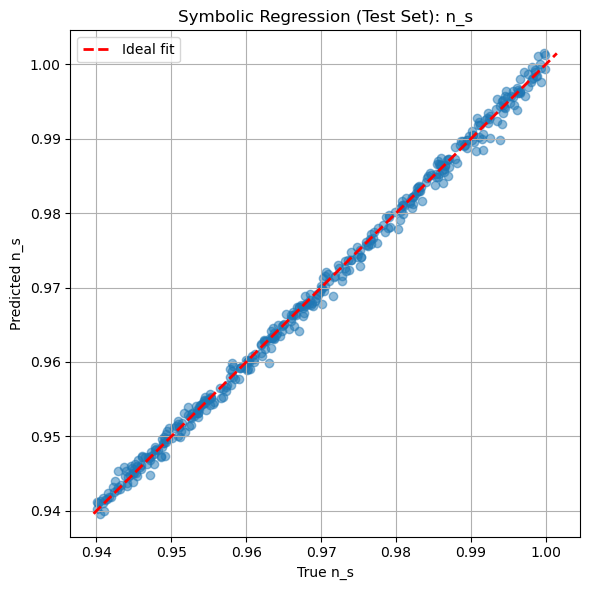

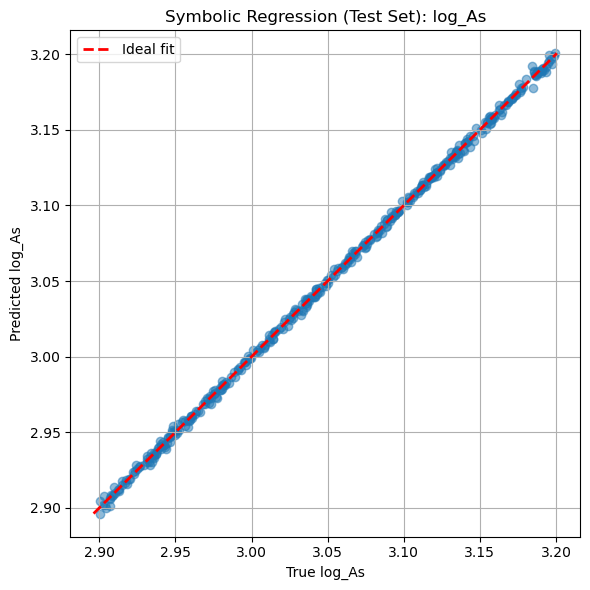

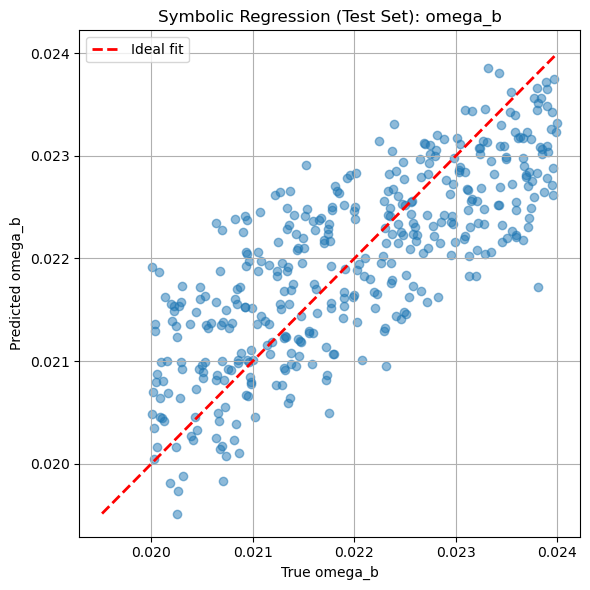

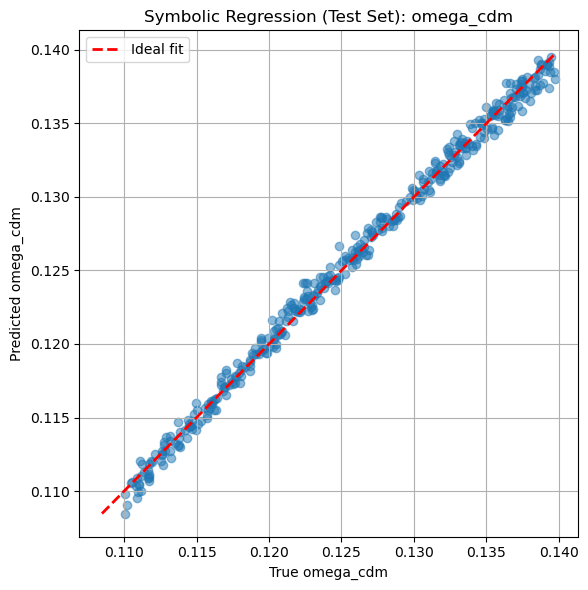

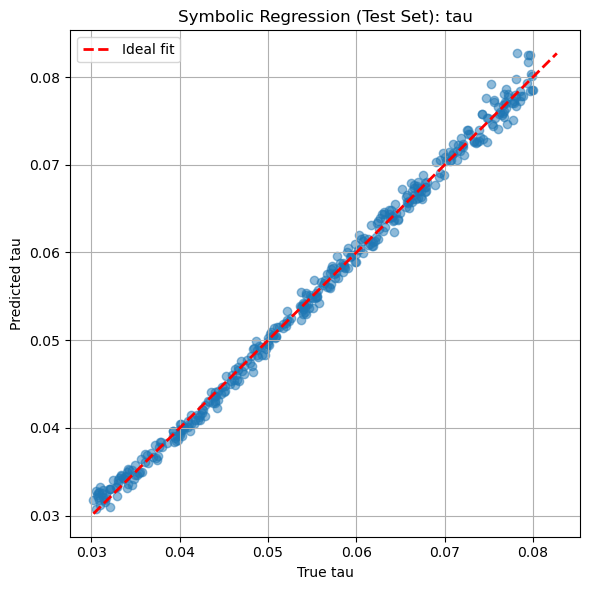

In [70]:
import matplotlib.pyplot as plt

# Use TEST data for evaluation (important!)
targets_test = {
    "n_s": y_test_ns,
    "log_As": y_test_log_As,
    "omega_b": y_test_omega_b,
    "omega_cdm": y_test_omega_cdm,
    "tau": y_test_tau,
}

# Loop through each parameter and its trained model
for param, model in symbolic_models_full.items():
    y_true = targets_test[param]
    y_pred = model.predict(X_test_scaled)

    plt.figure(figsize=(6, 6))
    plt.scatter(y_true, y_pred, alpha=0.5)

    # Ideal line
    min_val = min(y_true.min(), y_pred.min())
    max_val = max(y_true.max(), y_pred.max())

    plt.plot([min_val, max_val],
             [min_val, max_val],
             "r--", lw=2, label="Ideal fit")

    plt.xlabel(f"True {param}")
    plt.ylabel(f"Predicted {param}")
    plt.title(f"Symbolic Regression (Test Set): {param}")
    plt.grid(True)
    plt.legend()
    plt.savefig(f"figures/full_{param}_pred_vs_true.png", dpi=300, bbox_inches="tight")
    plt.tight_layout()
    plt.show()

In [12]:
full_equations = {}

for param, model in symbolic_models_full.items():
    eqn = model.get_best().equation
    latex_eqn = model.latex()

    full_equations[param] = {
        "equation": eqn,
        "latex": latex_eqn
    }

    print(f"\n=== {param} ===")
    print("Equation:", eqn)
    print("LaTeX:", latex_eqn)


=== n_s ===
Equation: sqrt(log(sqrt(sqrt(sqrt(sqrt(exp(x764 + (14.965226 - (x2036 * 1.4049994))))) + (x14 + (cos(cos(x1964)) + (x2036 * 1.9773506)))))))
LaTeX: \sqrt{\log{\left(\sqrt[4]{x_{14} + 1.98 x_{2036} + 42.2 \sqrt[4]{e^{- 1.41 x_{2036} + x_{764}}} + \cos{\left(\cos{\left(x_{1964} \right)} \right)}} \right)}}

=== log_As ===
Equation: 4.05328 - exp(((x2229 - (x808 - (cos(x1978) - cos(x1005)))) * 0.0058079883) - (((x746 + (x828 + x794)) + x1005) * 0.028408984))
LaTeX: 4.05 - e^{\left(x_{2229} - \left(x_{808} - \left(- \cos{\left(x_{1005} \right)} + \cos{\left(x_{1978} \right)}\right)\right)\right) 0.00581 - \left(x_{1005} + x_{746} + x_{794} + x_{828}\right) 0.0284}

=== omega_b ===
Equation: sin(sin(cos(1.2253418 - (x1424 * 0.016889447)) / -0.69381815)) * -0.048719898
LaTeX: \sin{\left(\sin{\left(\frac{\cos{\left(1.23 - x_{1424} \cdot 0.0169 \right)}}{-0.694} \right)} \right)} \left(-0.0487\right)

=== omega_cdm ===
Equation: 0.12405881 - ((x1689 + (x507 + ((x305 + ((((x507 + x

UnicodeDecodeError: 'utf-8' codec can't decode bytes in position 4094-4095: unexpected end of data

In [13]:
# --- Pretty-print equations with human-readable feature names (TT_lℓ, TE_lℓ, EE_lℓ) ---

import re

ELL_TRUNCATE = X.shape[1] // 3  # e.g., 1000 if ell_truncate=1000

def idx_to_name(i):
    i = int(i)
    if i < ELL_TRUNCATE:
        return f"TT_l{i}"
    elif i < 2 * ELL_TRUNCATE:
        return f"TE_l{i - ELL_TRUNCATE}"
    else:
        return f"EE_l{i - 2 * ELL_TRUNCATE}"

def pretty_equation(eq_str):
    return re.sub(r"x(\d+)", lambda m: idx_to_name(m.group(1)), eq_str)

for param, model in symbolic_models_full.items():
    try:
        eqn = model.get_best().equation
    except Exception:
        eqn = model.equations_.iloc[-1]["equation"]

    print(f"\n=== {param} ===")
    print(pretty_equation(eqn))


=== n_s ===
sqrt(log(sqrt(sqrt(sqrt(sqrt(exp(TT_l764 + (14.965226 - (EE_l36 * 1.4049994))))) + (TT_l14 + (cos(cos(TE_l964)) + (EE_l36 * 1.9773506)))))))

=== log_As ===
4.05328 - exp(((EE_l229 - (TT_l808 - (cos(TE_l978) - cos(TE_l5)))) * 0.0058079883) - (((TT_l746 + (TT_l828 + TT_l794)) + TE_l5) * 0.028408984))

=== omega_b ===
sin(sin(cos(1.2253418 - (TE_l424 * 0.016889447)) / -0.69381815)) * -0.048719898

=== omega_cdm ===
0.12405881 - ((TE_l689 + (TT_l507 + ((TT_l305 + ((((TT_l507 + TE_l933) + TE_l604) * 0.069634184) * (EE_l767 + 0.124764))) * -0.37057927))) * 0.011106531)

=== tau ===
0.05690872 - sin(((TE_l23 - (((TE_l23 * -0.4738523) - EE_l2) * sin(EE_l2))) - (EE_l2 * 4.6716633)) * 0.003019309)
Error in callback _flush_stdio (for post_execute), with arguments args (),kwargs {}:


UnicodeDecodeError: 'utf-8' codec can't decode bytes in position 4094-4095: unexpected end of data

In [14]:
# --- Pretty LaTeX equations with TT_lℓ, TE_lℓ, EE_lℓ notation ---

import re

ELL_TRUNCATE = X.shape[1] // 3  # e.g., 1000

def idx_to_name_latex(i):
    i = int(i)
    if i < ELL_TRUNCATE:
        return rf"\mathrm{{TT}}_{{\ell={i}}}"
    elif i < 2 * ELL_TRUNCATE:
        return rf"\mathrm{{TE}}_{{\ell={i - ELL_TRUNCATE}}}"
    else:
        return rf"\mathrm{{EE}}_{{\ell={i - 2 * ELL_TRUNCATE}}}"

def pretty_latex(latex_str):
    return re.sub(r"x_{(\d+)}", lambda m: idx_to_name_latex(m.group(1)), latex_str)

# Store LaTeX equations for later use
latex_equations_pretty = {}

for param, model in symbolic_models_full.items():
    try:
        raw_latex = model.latex()
    except Exception:
        raw_latex = model.sympy()._repr_latex_()

    pretty = pretty_latex(raw_latex)
    latex_equations_pretty[param] = pretty

    print(f"\n=== {param} ===\n")
    print(pretty)


=== n_s ===

\sqrt{\log{\left(\sqrt[4]{\mathrm{TT}_{\ell=14} + 1.98 \mathrm{EE}_{\ell=36} + 42.2 \sqrt[4]{e^{- 1.41 \mathrm{EE}_{\ell=36} + \mathrm{TT}_{\ell=764}}} + \cos{\left(\cos{\left(\mathrm{TE}_{\ell=964} \right)} \right)}} \right)}}

=== log_As ===

4.05 - e^{\left(\mathrm{EE}_{\ell=229} - \left(\mathrm{TT}_{\ell=808} - \left(- \cos{\left(\mathrm{TE}_{\ell=5} \right)} + \cos{\left(\mathrm{TE}_{\ell=978} \right)}\right)\right)\right) 0.00581 - \left(\mathrm{TE}_{\ell=5} + \mathrm{TT}_{\ell=746} + \mathrm{TT}_{\ell=794} + \mathrm{TT}_{\ell=828}\right) 0.0284}

=== omega_b ===

\sin{\left(\sin{\left(\frac{\cos{\left(1.23 - \mathrm{TE}_{\ell=424} \cdot 0.0169 \right)}}{-0.694} \right)} \right)} \left(-0.0487\right)

=== omega_cdm ===

0.124 - \left(\mathrm{TE}_{\ell=689} + \mathrm{TT}_{\ell=507} + \left(\mathrm{TT}_{\ell=305} + \left(\mathrm{TE}_{\ell=604} + \mathrm{TE}_{\ell=933} + \mathrm{TT}_{\ell=507}\right) 0.0696 \left(\mathrm{EE}_{\ell=767} + 0.125\right)\right) \left(-0.37

UnicodeDecodeError: 'utf-8' codec can't decode bytes in position 4094-4095: unexpected end of data

In [7]:
from pysr import PySRRegressor
from sklearn.metrics import r2_score, mean_absolute_error
import pandas as pd
import joblib
import numpy as np

# -------------------------------
# Restricted-operator final run
# -------------------------------

# Start with the most important interpretable parameters first.
# You can expand to all five if runtime is manageable.
params_to_rerun = ["n_s", "log_As", "omega_cdm", "tau"]

restricted_kwargs = {
    "niterations": 300,
    "binary_operators": ["+", "-", "*", "/"],
    "unary_operators": ["log", "sqrt"],
    "elementwise_loss": "L2DistLoss()",
    "model_selection": "best",
    "maxsize": 20,
    "precision": 32,
    "early_stop_condition": "f(l,c) = (l < 1e-6) && (c < 16)",
    "timeout_in_seconds": 3600,
    "parallelism": "multithreading",
    "verbosity": 1,
}

target_dict_train = {
    "n_s": y_train_ns,
    "log_As": y_train_log_As,
    "omega_b": y_train_omega_b,
    "omega_cdm": y_train_omega_cdm,
    "tau": y_train_tau,
}

target_dict_test = {
    "n_s": y_test_ns,
    "log_As": y_test_log_As,
    "omega_b": y_test_omega_b,
    "omega_cdm": y_test_omega_cdm,
    "tau": y_test_tau,
}

symbolic_models_restricted = {}
restricted_results = []

# Use 3 seeds for publication-grade stability
seeds = [0, 1, 2]

for p in params_to_rerun:
    ytr = target_dict_train[p]
    yte = target_dict_test[p]

    best_model = None
    best_r2 = -np.inf
    best_seed = None

    print(f"\n==============================")
    print(f"[RestrictedOps] Training {p}")
    print(f"==============================")

    for seed in seeds:
        print(f"\nSeed = {seed}")

        m = PySRRegressor(
            random_state=seed,
            **restricted_kwargs
        )

        m.fit(X_train_scaled, ytr)

        y_pred_test = m.predict(X_test_scaled)
        r2 = r2_score(yte, y_pred_test)
        mae = mean_absolute_error(yte, y_pred_test)

        restricted_results.append({
            "parameter": p,
            "seed": seed,
            "r2_test": r2,
            "mae_test": mae
        })

        print(f"[RestrictedOps] {p:10s} Test R2 = {r2:.4f}   Test MAE = {mae:.6f}")

        if r2 > best_r2:
            best_r2 = r2
            best_model = m
            best_seed = seed

    symbolic_models_restricted[p] = best_model
    joblib.dump(best_model, f"pysr_restricted_model_{p}.pkl")

    try:
        eqn = best_model.get_best().equation
    except Exception:
        eqn = best_model.equations_.iloc[-1]["equation"]

    print(f"[RestrictedOps] Best seed for {p}: {best_seed}")
    print("[RestrictedOps] Equation:")
    print(pretty_equation(eqn))

restricted_results_df = pd.DataFrame(restricted_results)
restricted_results_df.to_csv("pysr_restricted_operator_results.csv", index=False)

print("\nSaved:")
print("- Best restricted-operator models as .pkl")
print("- Restricted multi-seed results as pysr_restricted_operator_results.csv")

/opt/anaconda3/envs/env2/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
Compiling Julia backend...



[RestrictedOps] Training n_s

Seed = 0


/opt/anaconda3/envs/env2/lib/python3.12/site-packages/pysr/sr.py:1873: UserWarning: Note: Setting `random_state` without also setting `deterministic=True` and `parallelism='serial'` will result in non-deterministic searches.
  warnings.warn(
[ Info: Started!



Expressions evaluated per second: 1.910e+05
Progress: 1200 / 9300 total iterations (12.903%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           2.983e-04  0.000e+00  y = 0.9702
5           2.011e-04  9.859e-02  y = 0.9702 - (x₈ * 0.0098596)
7           1.629e-05  1.257e+00  y = ((x₇₇₇ - x₂₀₄₇) * 0.034737) + 0.9702
8           1.432e-05  1.288e-01  y = sqrt((-0.068492 * (x₂₀₄₇ - x₇₆₉)) - -0.94159)
9           6.290e-06  8.228e-01  y = (((x₇₇₂ * 0.86147) - x₁₀₂₆) * 0.030655) - -0.9702
11          4.839e-06  1.311e-01  y = (((x₇₇₇ - x₁₀₂₆) * 0.030513) + 0.9702) - (x₂₉₉₉ * 0.00...
                                      46188)
12          3.698e-06  2.689e-01  y = sqrt((-0.0069706 * x₂₉₉₁) + (((x₂₀₄₇ - x₇₇₇) * -0.0710...
                                      83) - -0.94159))
15          2.

[ Info: Final population:
[ Info: Results saved to:


...


Expressions evaluated per second: 2.020e+05
Progress: 1225 / 9300 total iterations (13.172%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           2.983e-04  0.000e+00  y = 0.9702
5           1.880e-04  1.154e-01  y = (x₅ * -0.010503) + 0.9702
7           1.614e-05  1.228e+00  y = 0.9702 + ((x₁₀₇₁ + x₈₂₄) * 0.039624)
9           5.250e-06  5.614e-01  y = (x₇₆₃ * 0.026813) + ((x₂₀₂₃ * -0.03107) + 0.9702)
10          4.590e-06  1.345e-01  y = sqrt((x₇₇₀ * 0.052593) + 0.94202) + (x₂₀₂₄ * -0.031278...
                                      )
13          4.434e-06  1.152e-02  y = (((x₇₆₃ + (x₁₅₅₃ * -0.041545)) * 0.027398) + (x₂₀₂₄ * ...
                                      -0.031242)) + 0.9702
15          3.681e-06  9.301e-02  y = (-0.032664 * x₂₀₂₄) + (((((x₉₆₉ + x₁₀₁₁) * 0.055358) +...
   

[ Info: Final population:
[ Info: Results saved to:


[RestrictedOps] n_s        Test R2 = 0.9933   Test MAE = 0.001121
[RestrictedOps] Best seed for n_s: 1
[RestrictedOps] Equation:


NameError: name 'pretty_equation' is not defined

  - outputs/20260411_191519_B5UQic/hall_of_fame.csv


In [8]:
import re

ELL_TRUNCATE = X.shape[1] // 3  # should be 1000

def idx_to_name(i):
    i = int(i)
    if i < ELL_TRUNCATE:
        return f"TT_l{i}"
    elif i < 2 * ELL_TRUNCATE:
        return f"TE_l{i - ELL_TRUNCATE}"
    else:
        return f"EE_l{i - 2 * ELL_TRUNCATE}"

def pretty_equation(eq_str):
    return re.sub(r"x(\d+)", lambda m: idx_to_name(m.group(1)), eq_str)

In [9]:
from pysr import PySRRegressor
from sklearn.metrics import r2_score, mean_absolute_error
import pandas as pd
import joblib
import numpy as np
import os

# -------------------------------
# Restricted-operator recovery run
# -------------------------------

params_to_rerun = ["log_As", "omega_cdm", "tau"]

restricted_kwargs = {
    "niterations": 300,
    "binary_operators": ["+", "-", "*", "/"],
    "unary_operators": ["log", "sqrt"],
    "elementwise_loss": "L2DistLoss()",
    "model_selection": "best",
    "maxsize": 20,
    "precision": 32,
    "early_stop_condition": "f(l,c) = (l < 1e-6) && (c < 16)",
    "timeout_in_seconds": 3600,
    "parallelism": "multithreading",
    "verbosity": 1,
}

target_dict_train = {
    "n_s": y_train_ns,
    "log_As": y_train_log_As,
    "omega_b": y_train_omega_b,
    "omega_cdm": y_train_omega_cdm,
    "tau": y_train_tau,
}

target_dict_test = {
    "n_s": y_test_ns,
    "log_As": y_test_log_As,
    "omega_b": y_test_omega_b,
    "omega_cdm": y_test_omega_cdm,
    "tau": y_test_tau,
}

# load existing n_s model
symbolic_models_restricted = {}
restricted_results = []

if os.path.exists("pysr_restricted_model_n_s.pkl"):
    model_ns = joblib.load("pysr_restricted_model_n_s.pkl")
    symbolic_models_restricted["n_s"] = model_ns

    y_pred_test = model_ns.predict(X_test_scaled)
    r2 = r2_score(y_test_ns, y_pred_test)
    mae = mean_absolute_error(y_test_ns, y_pred_test)

    restricted_results.append({
        "parameter": "n_s",
        "seed": "best_loaded",
        "r2_test": r2,
        "mae_test": mae
    })

    print(f"[Loaded existing] n_s        Test R2 = {r2:.4f}   Test MAE = {mae:.6f}")

# Use 3 seeds for publication-grade stability
seeds = [0, 1, 2]

for p in params_to_rerun:
    ytr = target_dict_train[p]
    yte = target_dict_test[p]

    best_model = None
    best_r2 = -np.inf
    best_seed = None

    print(f"\n==============================")
    print(f"[RestrictedOps] Training {p}")
    print(f"==============================")

    for seed in seeds:
        print(f"\nSeed = {seed}")

        try:
            m = PySRRegressor(
                random_state=seed,
                **restricted_kwargs
            )

            m.fit(X_train_scaled, ytr)

            y_pred_test = m.predict(X_test_scaled)
            r2 = r2_score(yte, y_pred_test)
            mae = mean_absolute_error(yte, y_pred_test)

            restricted_results.append({
                "parameter": p,
                "seed": seed,
                "r2_test": r2,
                "mae_test": mae
            })

            print(f"[RestrictedOps] {p:10s} Test R2 = {r2:.4f}   Test MAE = {mae:.6f}")

            if r2 > best_r2:
                best_r2 = r2
                best_model = m
                best_seed = seed

        except Exception as e:
            print(f"Seed {seed} failed for {p}: {e}")

    if best_model is None:
        raise RuntimeError(f"No successful restricted model found for {p}")

    symbolic_models_restricted[p] = best_model
    joblib.dump(best_model, f"pysr_restricted_model_{p}.pkl")

    try:
        eqn = best_model.get_best().equation
    except Exception:
        eqn = best_model.equations_.iloc[-1]["equation"]

    print(f"[RestrictedOps] Best seed for {p}: {best_seed}")
    print("[RestrictedOps] Equation:")
    print(pretty_equation(eqn))

    # save partial results after each parameter
    restricted_results_df = pd.DataFrame(restricted_results)
    restricted_results_df.to_csv("pysr_restricted_operator_results_partial.csv", index=False)

# final save
restricted_results_df = pd.DataFrame(restricted_results)
restricted_results_df.to_csv("pysr_restricted_operator_results.csv", index=False)

print("\nSaved:")
print("- Best restricted-operator models as .pkl")
print("- Restricted results as pysr_restricted_operator_results.csv")

[Loaded existing] n_s        Test R2 = 0.9977   Test MAE = 0.000654

[RestrictedOps] Training log_As

Seed = 0


/opt/anaconda3/envs/env2/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
/opt/anaconda3/envs/env2/lib/python3.12/site-packages/pysr/sr.py:1873: UserWarning: Note: Setting `random_state` without also setting `deterministic=True` and `parallelism='serial'` will result in non-deterministic searches.
  warnings.warn(
[ Info: Started!



Expressions evaluated per second: 1.970e+05
Progress: 1199 / 9300 total iterations (12.892%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           7.511e-03  0.000e+00  y = 3.0495
4           1.983e-03  4.439e-01  y = log(x₇₉₄ + 21.093)
5           7.833e-04  9.290e-01  y = (x₇₉₂ * 0.082022) + 3.0495
7           7.833e-04  1.788e-07  y = 0.71244 - ((x₇₉₂ * -0.082022) + -2.337)
8           7.750e-04  1.057e-02  y = sqrt((x₇₉₀ * 0.25536) + 2.4173) + 1.4969
9           7.477e-05  2.339e+00  y = ((x₇₉₂ * 0.080171) - (x₁₀₀₁ * -0.026682)) + 3.0495
11          7.477e-05  5.364e-07  y = (((x₁₀₀₁ * -0.055252) / -2.0707) - -3.0495) + (x₇₉₂ * ...
                                      0.080171)
13          6.081e-05  1.033e-01  y = (((x₁₁₄₂ * -0.24457) - x₁₀₀₁) * -0.025403) - ((x₇₉₂ * ...
         

[ Info: Final population:
[ Info: Results saved to:


[RestrictedOps] log_As     Test R2 = 0.9986   Test MAE = 0.002525

Seed = 1
  - outputs/20260411_193632_0IVBu1/hall_of_fame.csv


...

[RestrictedOps] tau        Test R2 = 0.9984   Test MAE = 0.000458

Seed = 2
  - outputs/20260411_193929_CoUWef/hall_of_fame.csv


/opt/anaconda3/envs/env2/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
/opt/anaconda3/envs/env2/lib/python3.12/site-packages/pysr/sr.py:1873: UserWarning: Note: Setting `random_state` without also setting `deterministic=True` and `parallelism='serial'` will result in non-deterministic searches.
  warnings.warn(
[ Info: Started!
[ Info: Final population:


───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           2.083e-04  0.000e+00  y = 0.054935
5           1.531e-05  6.526e-01  y = (x₂₀₀₈ + 3.9543) * 0.013893
6           9.404e-06  4.874e-01  y = sqrt(x₂₀₀₈ + 2.0081) * 0.040023
8           8.564e-06  4.682e-02  y = (sqrt(x₂₀₀₈ + 1.5242) * 0.033225) + 0.016439
10          8.480e-07  1.156e+00  y = ((x₂₀₃₄ * -0.0020673) - -0.039305) * sqrt(x₂₀₀₂ + 2.07...
                                      46)
───────────────────────────────────────────────────────────────────────────────────────────────────


[ Info: Results saved to:


[RestrictedOps] tau        Test R2 = 0.9960   Test MAE = 0.000736
[RestrictedOps] Best seed for tau: 1
[RestrictedOps] Equation:
0.014767303 - (((((TT_l788 + TE_l393) + (TE_l108 * 2.1543493)) * -0.0017324582) + -0.033914566) * sqrt(EE_l8 + 1.5720251))

Saved:
- Best restricted-operator models as .pkl
- Restricted results as pysr_restricted_operator_results.csv
  - outputs/20260411_194005_RsJ6zW/hall_of_fame.csv


In [10]:
import os

for fname in [
    "pysr_restricted_model_n_s.pkl",
    "pysr_restricted_model_log_As.pkl",
    "pysr_restricted_model_omega_cdm.pkl",
    "pysr_restricted_model_tau.pkl",
    "pysr_restricted_operator_results.csv",
]:
    print(fname, os.path.exists(fname))

pysr_restricted_model_n_s.pkl True
pysr_restricted_model_log_As.pkl True
pysr_restricted_model_omega_cdm.pkl True
pysr_restricted_model_tau.pkl True
pysr_restricted_operator_results.csv True


In [11]:
import pandas as pd
restricted_results_df = pd.read_csv("pysr_restricted_operator_results.csv")
print(restricted_results_df)

   parameter         seed   r2_test  mae_test
0        n_s  best_loaded  0.997668  0.000654
1     log_As            0  0.998616  0.002525
2     log_As            1  0.998938  0.002268
3     log_As            2  0.996757  0.003843
4  omega_cdm            0  0.986615  0.000778
5  omega_cdm            1  0.984818  0.000833
6  omega_cdm            2  0.995267  0.000440
7        tau            0  0.997476  0.000582
8        tau            1  0.998365  0.000458
9        tau            2  0.996032  0.000736


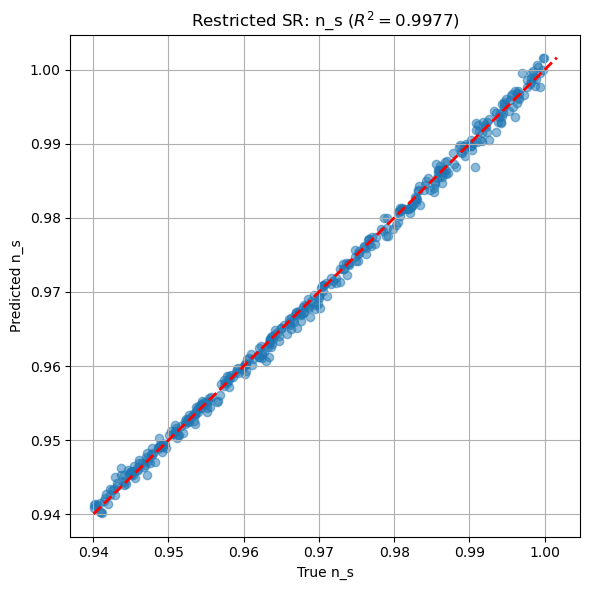

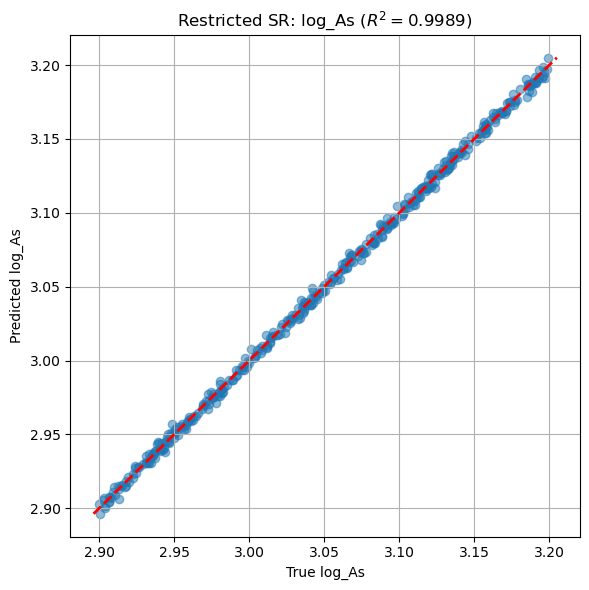

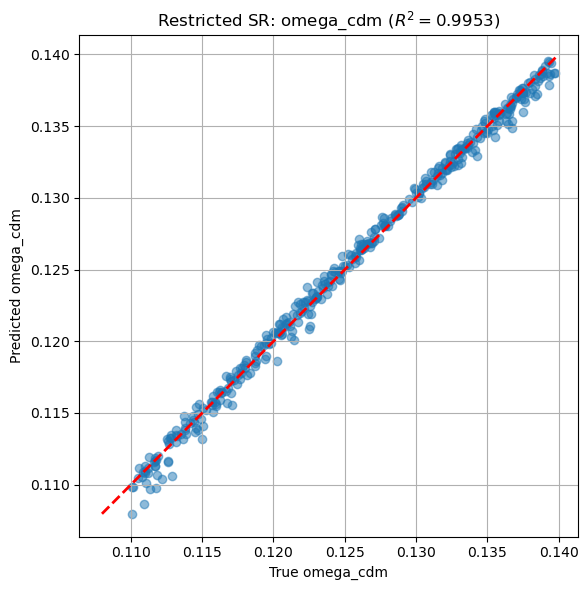

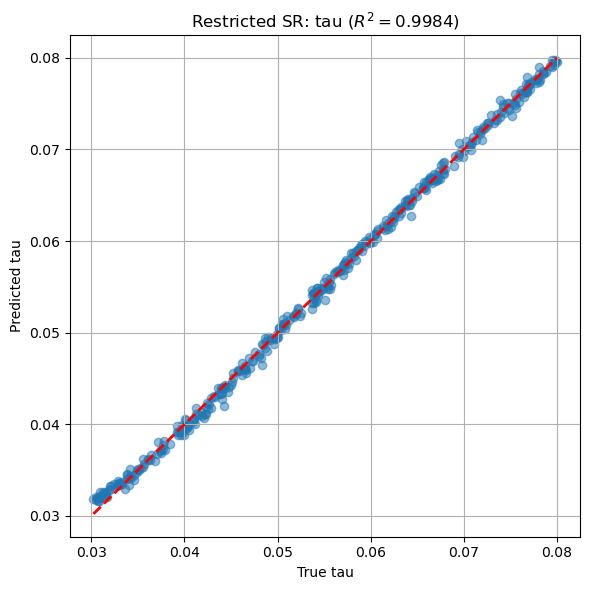

In [12]:
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

targets_test = {
    "n_s": y_test_ns,
    "log_As": y_test_log_As,
    "omega_cdm": y_test_omega_cdm,
    "tau": y_test_tau,
}

for param in ["n_s", "log_As", "omega_cdm", "tau"]:
    model = joblib.load(f"pysr_restricted_model_{param}.pkl")
    y_true = targets_test[param]
    y_pred = model.predict(X_test_scaled)

    r2 = r2_score(y_true, y_pred)

    plt.figure(figsize=(6, 6))
    plt.scatter(y_true, y_pred, alpha=0.5)

    min_val = min(y_true.min(), y_pred.min())
    max_val = max(y_true.max(), y_pred.max())

    plt.plot([min_val, max_val], [min_val, max_val], "r--", lw=2)

    plt.xlabel(f"True {param}")
    plt.ylabel(f"Predicted {param}")
    plt.title(f"Restricted SR: {param} ($R^2={r2:.4f}$)")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [13]:
for param in ["n_s", "log_As", "omega_cdm", "tau"]:
    model = joblib.load(f"pysr_restricted_model_{param}.pkl")
    try:
        eqn = model.get_best().equation
    except Exception:
        eqn = model.equations_.iloc[-1]["equation"]

    print(f"\n=== {param} ===")
    print(pretty_equation(eqn))


=== n_s ===
(((EE_l73 * 0.0033236402) + -0.037307825) * ((EE_l53 - EE_l454) + (EE_l431 - TT_l750))) + 0.96965224

=== log_As ===
log(TT_l812 + (((TT_l754 + ((TE_l6 + (TE_l570 + TE_l8)) * -0.20393687)) + TE_l5) + 21.183264))

=== omega_cdm ===
((TE_l840 * 0.011663058) - ((TE_l296 + 3.6445718) * (((TT_l930 + 0.8987217) + TE_l725) * -0.00084133167))) - -0.12191176

=== tau ===
0.014767303 - (((((TT_l788 + TE_l393) + (TE_l108 * 2.1543493)) * -0.0017324582) + -0.033914566) * sqrt(EE_l8 + 1.5720251))


In [15]:
import re

ELL_TRUNCATE = X.shape[1] // 3  # should be 1000

def idx_to_name_readable(i):
    i = int(i)
    if i < ELL_TRUNCATE:
        return f"TT_{{ell={i}}}"
    elif i < 2 * ELL_TRUNCATE:
        return f"TE_{{ell={i - ELL_TRUNCATE}}}"
    else:
        return f"EE_{{ell={i - 2 * ELL_TRUNCATE}}}"

def idx_to_name_latex(i):
    i = int(i)
    if i < ELL_TRUNCATE:
        return rf"\mathrm{{TT}}_{{\ell={i}}}"
    elif i < 2 * ELL_TRUNCATE:
        return rf"\mathrm{{TE}}_{{\ell={i - ELL_TRUNCATE}}}"
    else:
        return rf"\mathrm{{EE}}_{{\ell={i - 2 * ELL_TRUNCATE}}}"

def pretty_equation(eq_str):
    return re.sub(r"x(\d+)", lambda m: idx_to_name_readable(m.group(1)), eq_str)

def latex_equation(eq_str):
    eq = re.sub(r"x(\d+)", lambda m: idx_to_name_latex(m.group(1)), eq_str)
    eq = eq.replace("*", r" \cdot ")
    return eq

for param in ["n_s", "log_As", "omega_cdm", "tau"]:
    model = joblib.load(f"pysr_restricted_model_{param}.pkl")

    try:
        eqn = model.get_best().equation
    except Exception:
        eqn = model.equations_.iloc[-1]["equation"]

    print(f"\n==============================")
    print(param)
    print(f"==============================")

    print("\n[Readable]")
    print(pretty_equation(eqn))

    print("\n[LaTeX]")
    print(f"${param} = {latex_equation(eqn)}$")


n_s

[Readable]
(((EE_{ell=73} * 0.0033236402) + -0.037307825) * ((EE_{ell=53} - EE_{ell=454}) + (EE_{ell=431} - TT_{ell=750}))) + 0.96965224

[LaTeX]
$n_s = (((\mathrm{EE}_{\ell=73}  \cdot  0.0033236402) + -0.037307825)  \cdot  ((\mathrm{EE}_{\ell=53} - \mathrm{EE}_{\ell=454}) + (\mathrm{EE}_{\ell=431} - \mathrm{TT}_{\ell=750}))) + 0.96965224$

log_As

[Readable]
log(TT_{ell=812} + (((TT_{ell=754} + ((TE_{ell=6} + (TE_{ell=570} + TE_{ell=8})) * -0.20393687)) + TE_{ell=5}) + 21.183264))

[LaTeX]
$log_As = log(\mathrm{TT}_{\ell=812} + (((\mathrm{TT}_{\ell=754} + ((\mathrm{TE}_{\ell=6} + (\mathrm{TE}_{\ell=570} + \mathrm{TE}_{\ell=8}))  \cdot  -0.20393687)) + \mathrm{TE}_{\ell=5}) + 21.183264))$

omega_cdm

[Readable]
((TE_{ell=840} * 0.011663058) - ((TE_{ell=296} + 3.6445718) * (((TT_{ell=930} + 0.8987217) + TE_{ell=725}) * -0.00084133167))) - -0.12191176

[LaTeX]
$omega_cdm = ((\mathrm{TE}_{\ell=840}  \cdot  0.011663058) - ((\mathrm{TE}_{\ell=296} + 3.6445718)  \cdot  (((\mathrm{TT}_{

In [16]:
for param in ["n_s", "log_As", "omega_cdm", "tau"]:
    model = joblib.load(f"pysr_restricted_model_{param}.pkl")

    try:
        eqn = model.get_best().equation
    except Exception:
        eqn = model.equations_.iloc[-1]["equation"]

    print(f"\n% ===== {param} =====")
    print(r"\begin{equation}")
    print(f"{param} = {latex_equation(eqn)}")
    print(r"\end{equation}")


% ===== n_s =====
\begin{equation}
n_s = (((\mathrm{EE}_{\ell=73}  \cdot  0.0033236402) + -0.037307825)  \cdot  ((\mathrm{EE}_{\ell=53} - \mathrm{EE}_{\ell=454}) + (\mathrm{EE}_{\ell=431} - \mathrm{TT}_{\ell=750}))) + 0.96965224
\end{equation}

% ===== log_As =====
\begin{equation}
log_As = log(\mathrm{TT}_{\ell=812} + (((\mathrm{TT}_{\ell=754} + ((\mathrm{TE}_{\ell=6} + (\mathrm{TE}_{\ell=570} + \mathrm{TE}_{\ell=8}))  \cdot  -0.20393687)) + \mathrm{TE}_{\ell=5}) + 21.183264))
\end{equation}

% ===== omega_cdm =====
\begin{equation}
omega_cdm = ((\mathrm{TE}_{\ell=840}  \cdot  0.011663058) - ((\mathrm{TE}_{\ell=296} + 3.6445718)  \cdot  (((\mathrm{TT}_{\ell=930} + 0.8987217) + \mathrm{TE}_{\ell=725})  \cdot  -0.00084133167))) - -0.12191176
\end{equation}

% ===== tau =====
\begin{equation}
tau = 0.014767303 - (((((\mathrm{TT}_{\ell=788} + \mathrm{TE}_{\ell=393}) + (\mathrm{TE}_{\ell=108}  \cdot  2.1543493))  \cdot  -0.0017324582) + -0.033914566)  \cdot  sqrt(\mathrm{EE}_{\ell=8} + 1.

In [42]:
# --- Step 3A: Engineer baryon-sensitive features (peak ratios) and re-fit omega_b ---

import numpy as np
import pandas as pd
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error
from pysr import PySRRegressor

ELL_TRUNCATE = X.shape[1] // 3
TT = X[:, :ELL_TRUNCATE]  # TT block only

def band_avg(tt, ell0, w=5):
    lo = max(ell0 - w, 0)
    hi = min(ell0 + w + 1, tt.shape[1])
    return tt[:, lo:hi].mean(axis=1)

# Approximate acoustic peak locations (for ell in your indexing convention)
l1, l2, l3 = 220, 540, 800

p1 = band_avg(TT, l1, w=5)
p2 = band_avg(TT, l2, w=5)
p3 = band_avg(TT, l3, w=5)

eps = 1e-12

# Feature matrix for omega_b
Xb = np.column_stack([
    p1, p2, p3,
    p1 / (p2 + eps),
    p1 / (p3 + eps),
    p2 / (p3 + eps),
    (p1 - p2) / (p1 + p2 + eps),
    (p1 - p3) / (p1 + p3 + eps),
])

feature_names_b = [
    "p1", "p2", "p3",
    "p1_over_p2", "p1_over_p3", "p2_over_p3",
    "asym12", "asym13"
]

# Use the same target split philosophy as the main pipeline
# If you want exact alignment with existing X_train/X_test indices, see note below.
Xb_train, Xb_test, yb_train, yb_test = train_test_split(
    Xb, y[:, 2],   # omega_b column
    test_size=0.2,
    random_state=42
)

# Scale using training data only
sc_b = StandardScaler()
Xb_train_scaled = sc_b.fit_transform(Xb_train)
Xb_test_scaled  = sc_b.transform(Xb_test)

joblib.dump(sc_b, "omega_b_feature_scaler.pkl")

ob_kwargs = {
    "niterations": 300,
    "binary_operators": ["+", "-", "*", "/"],
    "unary_operators": ["log", "sqrt"],
    "elementwise_loss": "L2DistLoss()",
    "model_selection": "best",
    "maxsize": 16,
    "precision": 32,
    "early_stop_condition": "f(l,c) = (l < 5e-7) && (c < 14)",
    "timeout_in_seconds": 3600,
    "parallelism": "multithreading",
    "verbosity": 1,
}

seeds = [0, 1, 2]
omega_b_results = []
best_model = None
best_r2 = -np.inf
best_seed = None

print("\n[omega_b: peak ratios] Training...")

for seed in seeds:
    print(f"\nSeed = {seed}")

    model_ob_feats = PySRRegressor(
        random_state=seed,
        **ob_kwargs
    )

    model_ob_feats.fit(Xb_train_scaled, yb_train)

    yhat_test = model_ob_feats.predict(Xb_test_scaled)
    r2 = r2_score(yb_test, yhat_test)
    mae = mean_absolute_error(yb_test, yhat_test)

    omega_b_results.append({
        "parameter": "omega_b_engineered",
        "seed": seed,
        "r2_test": r2,
        "mae_test": mae
    })

    print(f"[omega_b: peak ratios] Test R2 = {r2:.4f}   Test MAE = {mae:.6f}")

    if r2 > best_r2:
        best_r2 = r2
        best_model = model_ob_feats
        best_seed = seed

# Save best model + results
joblib.dump(best_model, "pysr_restricted_model_omega_b_engineered.pkl")
omega_b_results_df = pd.DataFrame(omega_b_results)
omega_b_results_df.to_csv("pysr_omega_b_engineered_results.csv", index=False)

print(f"\nBest seed for engineered omega_b: {best_seed}")
print(f"Best Test R2 = {best_r2:.4f}")

try:
    eqn_ob = best_model.get_best().equation
except Exception:
    eqn_ob = best_model.equations_.iloc[-1]["equation"]

print("\n[omega_b: peak ratios] Raw equation:")
print(eqn_ob)


[omega_b: peak ratios] Training...

Seed = 0


/opt/anaconda3/envs/env2/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
/opt/anaconda3/envs/env2/lib/python3.12/site-packages/pysr/sr.py:1873: UserWarning: Note: Setting `random_state` without also setting `deterministic=True` and `parallelism='serial'` will result in non-deterministic searches.
  warnings.warn(
[ Info: Started!
[ Info: Final population:


───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           1.327e-06  0.000e+00  y = 0.022005
5           2.646e-07  4.030e-01  y = 0.022006 - (x₆ * -0.0010305)
───────────────────────────────────────────────────────────────────────────────────────────────────
[omega_b: peak ratios] Test R2 = 0.8005   Test MAE = 0.000439

Seed = 1
  - outputs/20260411_201946_R4NSRu/hall_of_fame.csv


[ Info: Results saved to:
/opt/anaconda3/envs/env2/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
/opt/anaconda3/envs/env2/lib/python3.12/site-packages/pysr/sr.py:1873: UserWarning: Note: Setting `random_state` without also setting `deterministic=True` and `parallelism='serial'` will result in non-deterministic searches.
  warnings.warn(
[ Info: Started!
[ Info: Final population:


───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           1.327e-06  0.000e+00  y = 0.022005
5           2.653e-07  4.024e-01  y = (x₃ * 0.0010302) + 0.022006
7           2.653e-07  1.490e-07  y = ((x₃ * 0.0025186) + 0.053802) / 2.4449
16          2.653e-07  2.881e-06  y = log((((((x₃ / 0.35319) + x₃) * 0.35319) / 0.5586) * 0....
                                      00070807) + 1.036) / 1.6047
───────────────────────────────────────────────────────────────────────────────────────────────────
[omega_b: peak ratios] Test R2 = 0.8016   Test MAE = 0.000437

Seed = 2
  - outputs/20260411_201947_SGPVxp/hall_of_fame.csv


[ Info: Results saved to:
/opt/anaconda3/envs/env2/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
/opt/anaconda3/envs/env2/lib/python3.12/site-packages/pysr/sr.py:1873: UserWarning: Note: Setting `random_state` without also setting `deterministic=True` and `parallelism='serial'` will result in non-deterministic searches.
  warnings.warn(
[ Info: Started!
[ Info: Final population:
[ Info: Results saved to:


───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           1.327e-06  0.000e+00  y = 0.022005
5           1.101e-06  4.671e-02  y = 0.022006 - (x₇ * -0.00047547)
9           2.847e-07  3.380e-01  y = (((x₆ + x₆) / 0.2483) * 0.00013094) + 0.021866
───────────────────────────────────────────────────────────────────────────────────────────────────
[omega_b: peak ratios] Test R2 = 0.7917   Test MAE = 0.000447

Best seed for engineered omega_b: 1
Best Test R2 = 0.8016

[omega_b: peak ratios] Raw equation:
(x3 * 0.0010301905) + 0.022005528
  - outputs/20260411_201947_vFEgyf/hall_of_fame.csv


In [43]:
import re

def pretty_ob_equation(eq_str):
    mapping = {
        "x0": "p1",
        "x1": "p2",
        "x2": "p3",
        "x3": "p1_over_p2",
        "x4": "p1_over_p3",
        "x5": "p2_over_p3",
        "x6": "asym12",
        "x7": "asym13",
    }
    for old, new in mapping.items():
        eq_str = eq_str.replace(old, new)
    return eq_str

print("\n[omega_b: peak ratios] Readable equation:")
print(pretty_ob_equation(eqn_ob))


[omega_b: peak ratios] Readable equation:
(p1_over_p2 * 0.0010301905) + 0.022005528


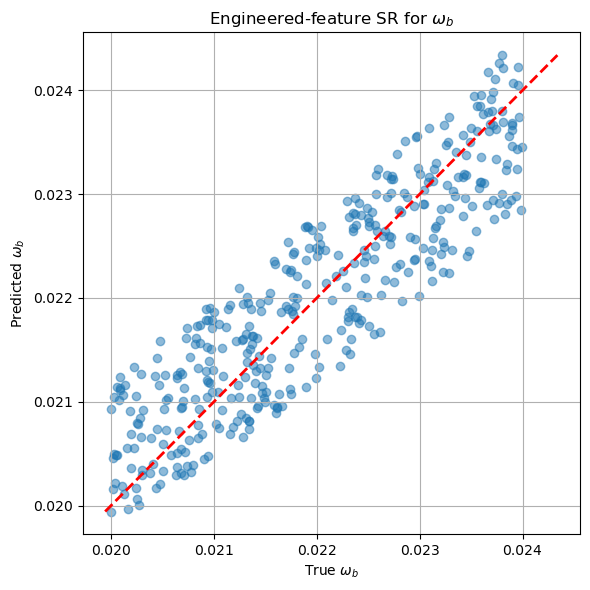

In [44]:
import matplotlib.pyplot as plt

yhat_test_best = best_model.predict(Xb_test_scaled)

plt.figure(figsize=(6, 6))
plt.scatter(yb_test, yhat_test_best, alpha=0.5)

min_val = min(yb_test.min(), yhat_test_best.min())
max_val = max(yb_test.max(), yhat_test_best.max())

plt.plot([min_val, max_val], [min_val, max_val], "r--", lw=2)
plt.xlabel(r"True $\omega_b$")
plt.ylabel(r"Predicted $\omega_b$")
plt.title(r"Engineered-feature SR for $\omega_b$")
plt.grid(True)
plt.tight_layout()
plt.show()

In [45]:
from sklearn.metrics import r2_score, mean_absolute_error

# Load best model + scaler
model_ob = joblib.load("pysr_restricted_model_omega_b_engineered.pkl")
sc_b = joblib.load("omega_b_feature_scaler.pkl")

# Recompute test predictions (safe + reproducible)
y_pred_test = model_ob.predict(Xb_test_scaled)

r2 = r2_score(yb_test, y_pred_test)
mae = mean_absolute_error(yb_test, y_pred_test)

print("\n=== Final omega_b (engineered features) ===")
print(f"Test R^2  : {r2:.4f}")
print(f"Test MAE  : {mae:.6f}")


=== Final omega_b (engineered features) ===
Test R^2  : 0.8016
Test MAE  : 0.000437


In [46]:
print(f"$R^2 = {r2:.4f}, \\quad \\mathrm{{MAE}} = {mae:.6f}$")

$R^2 = 0.8016, \quad \mathrm{MAE} = 0.000437$


# --- Step 3A: Engineer baryon-sensitive features (peak ratios) and re-fit omega_b ---

import numpy as np
import pandas as pd
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error
from pysr import PySRRegressor

ELL_TRUNCATE = X.shape[1] // 3
TT = X[:, :ELL_TRUNCATE]  # TT block only

def band_avg(tt, ell0, w=5):
    lo = max(ell0 - w, 0)
    hi = min(ell0 + w + 1, tt.shape[1])
    return tt[:, lo:hi].mean(axis=1)

# Approximate acoustic peak locations (for ell in your indexing convention)
l1, l2, l3 = 220, 540, 800

p1 = band_avg(TT, l1, w=5)
p2 = band_avg(TT, l2, w=5)
p3 = band_avg(TT, l3, w=5)

eps = 1e-12

# Feature matrix for omega_b
Xb = np.column_stack([
    # Original features
    p1, p2, p3,
    p1/(p2 + eps), p1/(p3 + eps), p2/(p3 + eps),
    (p1 - p2)/(p1 + p2 + eps),
    (p1 - p3)/(p1 + p3 + eps),

    # NEW physics-informed features
    (p1 - p2),              # odd-even contrast
    (p1 - 2*p2 + p3),       # curvature (VERY important)
])

feature_names_b = [
    "p1", "p2", "p3",
    "p1_over_p2", "p1_over_p3", "p2_over_p3",
    "asym12", "asym13",
    "odd_even",          # NEW
    "curvature"          # NEW
]

# Use the same target split philosophy as the main pipeline
# If you want exact alignment with existing X_train/X_test indices, see note below.
Xb_train, Xb_test, yb_train, yb_test = train_test_split(
    Xb, y[:, 2],   # omega_b column
    test_size=0.2,
    random_state=42
)

# Scale using training data only
sc_b = StandardScaler()
Xb_train_scaled = sc_b.fit_transform(Xb_train)
Xb_test_scaled  = sc_b.transform(Xb_test)

joblib.dump(sc_b, "omega_b_feature_scaler.pkl")

ob_kwargs = {
    "niterations": 300,
    "binary_operators": ["+", "-", "*", "/"],
    "unary_operators": ["log", "sqrt"],
    "elementwise_loss": "L2DistLoss()",
    "model_selection": "best",
    "maxsize": 16,
    "precision": 32,
    "early_stop_condition": "f(l,c) = (l < 5e-7) && (c < 14)",
    "timeout_in_seconds": 3600,
    "parallelism": "multithreading",
    "verbosity": 1,
}

seeds = [0, 1, 2]
omega_b_results = []
best_model = None
best_r2 = -np.inf
best_seed = None

print("\n[omega_b: peak ratios] Training...")

for seed in seeds:
    print(f"\nSeed = {seed}")

    model_ob_feats = PySRRegressor(
        random_state=seed,
        **ob_kwargs
    )

    model_ob_feats.fit(Xb_train_scaled, yb_train)

    yhat_test = model_ob_feats.predict(Xb_test_scaled)
    r2 = r2_score(yb_test, yhat_test)
    mae = mean_absolute_error(yb_test, yhat_test)

    omega_b_results.append({
        "parameter": "omega_b_engineered",
        "seed": seed,
        "r2_test": r2,
        "mae_test": mae
    })

    print(f"[omega_b: peak ratios] Test R2 = {r2:.4f}   Test MAE = {mae:.6f}")

    if r2 > best_r2:
        best_r2 = r2
        best_model = model_ob_feats
        best_seed = seed

# Save best model + results
joblib.dump(best_model, "pysr_restricted_model_omega_b_engineered.pkl")
omega_b_results_df = pd.DataFrame(omega_b_results)
omega_b_results_df.to_csv("pysr_omega_b_engineered_results.csv", index=False)

print(f"\nBest seed for engineered omega_b: {best_seed}")
print(f"Best Test R2 = {best_r2:.4f}")

try:
    eqn_ob = best_model.get_best().equation
except Exception:
    eqn_ob = best_model.equations_.iloc[-1]["equation"]

print("\n[omega_b: peak ratios] Raw equation:")
print(eqn_ob)

import re

def pretty_ob_equation(eq_str):
    mapping = {
        "x0": "p1",
        "x1": "p2",
        "x2": "p3",
        "x3": "p1_over_p2",
        "x4": "p1_over_p3",
        "x5": "p2_over_p3",
        "x6": "asym12",
        "x7": "asym13",
        "x8": "odd_even",
        "x9": "curvature",
    }
    for old, new in mapping.items():
        eq_str = eq_str.replace(old, new)
    return eq_str

print("\n[omega_b: peak ratios] Readable equation:")
print(pretty_ob_equation(eqn_ob))

import matplotlib.pyplot as plt

yhat_test_best = best_model.predict(Xb_test_scaled)

plt.figure(figsize=(6, 6))
plt.scatter(yb_test, yhat_test_best, alpha=0.5)

min_val = min(yb_test.min(), yhat_test_best.min())
max_val = max(yb_test.max(), yhat_test_best.max())

plt.plot([min_val, max_val], [min_val, max_val], "r--", lw=2)
plt.xlabel(r"True $\omega_b$")
plt.ylabel(r"Predicted $\omega_b$")
plt.title(r"Engineered-feature SR for $\omega_b$")
plt.grid(True)
plt.tight_layout()
plt.show()

from sklearn.metrics import r2_score, mean_absolute_error

# Load best model + scaler
model_ob = joblib.load("pysr_restricted_model_omega_b_engineered.pkl")
sc_b = joblib.load("omega_b_feature_scaler.pkl")

# Recompute test predictions (safe + reproducible)
y_pred_test = model_ob.predict(Xb_test_scaled)

r2 = r2_score(yb_test, y_pred_test)
mae = mean_absolute_error(yb_test, y_pred_test)

print("\n=== Final omega_b (engineered features) ===")
print(f"Test R^2  : {r2:.4f}")
print(f"Test MAE  : {mae:.6f}")

print(f"$R^2 = {r2:.4f}, \\quad \\mathrm{{MAE}} = {mae:.6f}$")

# --- Step 3A: Engineer baryon-sensitive features (peak ratios) and re-fit omega_b ---

import numpy as np
import pandas as pd
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error
from pysr import PySRRegressor

ELL_TRUNCATE = X.shape[1] // 3
TT = X[:, :ELL_TRUNCATE]  # TT block only

def band_avg(tt, ell0, w=5):
    lo = max(ell0 - w, 0)
    hi = min(ell0 + w + 1, tt.shape[1])
    return tt[:, lo:hi].mean(axis=1)

# Approximate acoustic peak locations (for ell in your indexing convention)
l1, l2, l3 = 220, 540, 800

p1 = band_avg(TT, l1, w=5)
p2 = band_avg(TT, l2, w=5)
p3 = band_avg(TT, l3, w=5)

eps = 1e-12

# Feature matrix for omega_b
Xb = np.column_stack([
    # Original features
    p1, p2, p3,
    p1/(p2 + eps), p1/(p3 + eps), p2/(p3 + eps),
    (p1 - p2)/(p1 + p2 + eps),
    (p1 - p3)/(p1 + p3 + eps),

    # NEW physics-informed features
    (p1 - 2*p2 + p3),       # curvature (VERY important)
])

feature_names_b = [
    "p1", "p2", "p3",
    "p1_over_p2", "p1_over_p3", "p2_over_p3",
    "asym12", "asym13",
    "curvature"          # NEW
]

# Use the same target split philosophy as the main pipeline
# If you want exact alignment with existing X_train/X_test indices, see note below.
Xb_train, Xb_test, yb_train, yb_test = train_test_split(
    Xb, y[:, 2],   # omega_b column
    test_size=0.2,
    random_state=42
)

# Scale using training data only
sc_b = StandardScaler()
Xb_train_scaled = sc_b.fit_transform(Xb_train)
Xb_test_scaled  = sc_b.transform(Xb_test)

joblib.dump(sc_b, "omega_b_feature_scaler.pkl")

ob_kwargs = {
    "niterations": 300,
    "binary_operators": ["+", "-", "*", "/"],
    "unary_operators": ["log", "sqrt"],
    "elementwise_loss": "L2DistLoss()",
    "model_selection": "best",
    "maxsize": 16,
    "precision": 32,
    "early_stop_condition": "f(l,c) = (l < 5e-7) && (c < 14)",
    "timeout_in_seconds": 3600,
    "parallelism": "multithreading",
    "verbosity": 1,
}

seeds = [0, 1, 2]
omega_b_results = []
best_model = None
best_r2 = -np.inf
best_seed = None

print("\n[omega_b: peak ratios] Training...")

for seed in seeds:
    print(f"\nSeed = {seed}")

    model_ob_feats = PySRRegressor(
        random_state=seed,
        **ob_kwargs
    )

    model_ob_feats.fit(Xb_train_scaled, yb_train)

    yhat_test = model_ob_feats.predict(Xb_test_scaled)
    r2 = r2_score(yb_test, yhat_test)
    mae = mean_absolute_error(yb_test, yhat_test)

    omega_b_results.append({
        "parameter": "omega_b_engineered",
        "seed": seed,
        "r2_test": r2,
        "mae_test": mae
    })

    print(f"[omega_b: peak ratios] Test R2 = {r2:.4f}   Test MAE = {mae:.6f}")

    if r2 > best_r2:
        best_r2 = r2
        best_model = model_ob_feats
        best_seed = seed

# Save best model + results
joblib.dump(best_model, "pysr_restricted_model_omega_b_engineered.pkl")
omega_b_results_df = pd.DataFrame(omega_b_results)
omega_b_results_df.to_csv("pysr_omega_b_engineered_results.csv", index=False)

print(f"\nBest seed for engineered omega_b: {best_seed}")
print(f"Best Test R2 = {best_r2:.4f}")

try:
    eqn_ob = best_model.get_best().equation
except Exception:
    eqn_ob = best_model.equations_.iloc[-1]["equation"]

print("\n[omega_b: peak ratios] Raw equation:")
print(eqn_ob)

import re

def pretty_ob_equation(eq_str):
    mapping = {
        "x0": "p1",
        "x1": "p2",
        "x2": "p3",
        "x3": "p1_over_p2",
        "x4": "p1_over_p3",
        "x5": "p2_over_p3",
        "x6": "asym12",
        "x7": "asym13",
        "x8": "curvature",
    }
    for old, new in mapping.items():
        eq_str = eq_str.replace(old, new)
    return eq_str

print("\n[omega_b: peak ratios] Readable equation:")
print(pretty_ob_equation(eqn_ob))

import matplotlib.pyplot as plt

yhat_test_best = best_model.predict(Xb_test_scaled)

plt.figure(figsize=(6, 6))
plt.scatter(yb_test, yhat_test_best, alpha=0.5)

min_val = min(yb_test.min(), yhat_test_best.min())
max_val = max(yb_test.max(), yhat_test_best.max())

plt.plot([min_val, max_val], [min_val, max_val], "r--", lw=2)
plt.xlabel(r"True $\omega_b$")
plt.ylabel(r"Predicted $\omega_b$")
plt.title(r"Engineered-feature SR for $\omega_b$")
plt.grid(True)
plt.tight_layout()
plt.show()

from sklearn.metrics import r2_score, mean_absolute_error

# Load best model + scaler
model_ob = joblib.load("pysr_restricted_model_omega_b_engineered.pkl")
sc_b = joblib.load("omega_b_feature_scaler.pkl")

# Recompute test predictions (safe + reproducible)
y_pred_test = model_ob.predict(Xb_test_scaled)

r2 = r2_score(yb_test, y_pred_test)
mae = mean_absolute_error(yb_test, y_pred_test)

print("\n=== Final omega_b (engineered features) ===")
print(f"Test R^2  : {r2:.4f}")
print(f"Test MAE  : {mae:.6f}")

print(f"$R^2 = {r2:.4f}, \\quad \\mathrm{{MAE}} = {mae:.6f}$")

In [47]:
print(pretty_ob_equation(eqn_ob))

(p1_over_p2 * 0.0010301905) + 0.022005528


In [48]:
print(f"$\\omega_b = {latex_equation(eqn_ob)}$")

$\omega_b = (\mathrm{TT}_{\ell=3}  \cdot  0.0010301905) + 0.022005528$


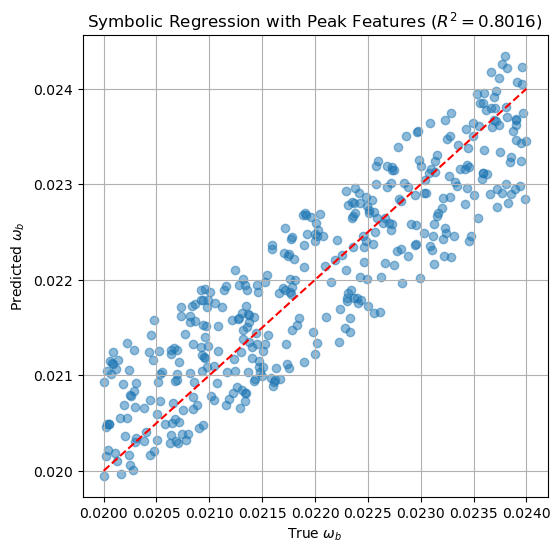

In [57]:
plt.figure(figsize=(6,6))
plt.scatter(yb_test, yhat_test_best, alpha=0.5)

plt.plot(
    [yb_test.min(), yb_test.max()],
    [yb_test.min(), yb_test.max()],
    "r--"
)

plt.xlabel(r"True $\omega_b$")
plt.ylabel(r"Predicted $\omega_b$")
plt.title(r"Symbolic Regression with Peak Features ($R^2=0.8016$)")
plt.savefig("figures/omega_b_engineered_pred_vs_true.png", dpi=300, bbox_inches="tight")
plt.grid(True)
plt.show()

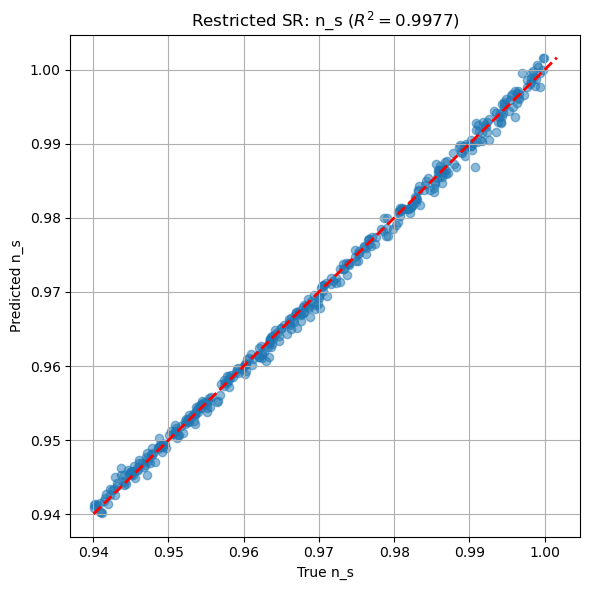

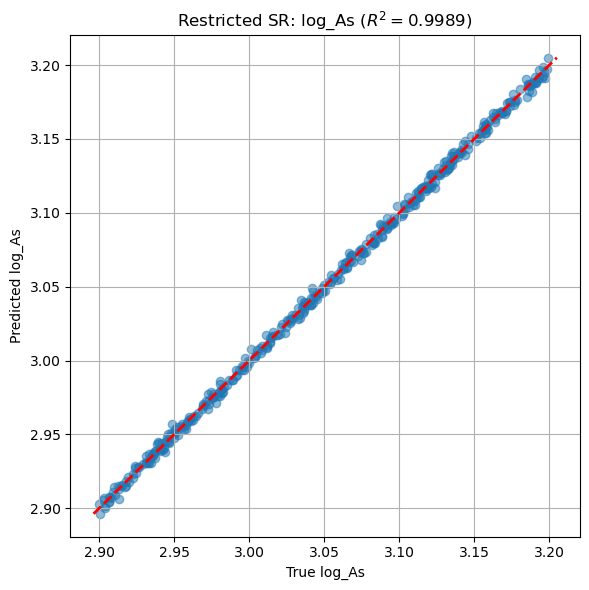

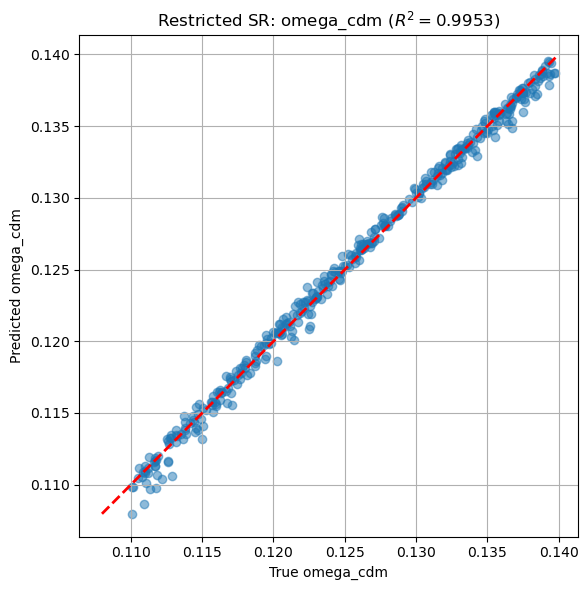

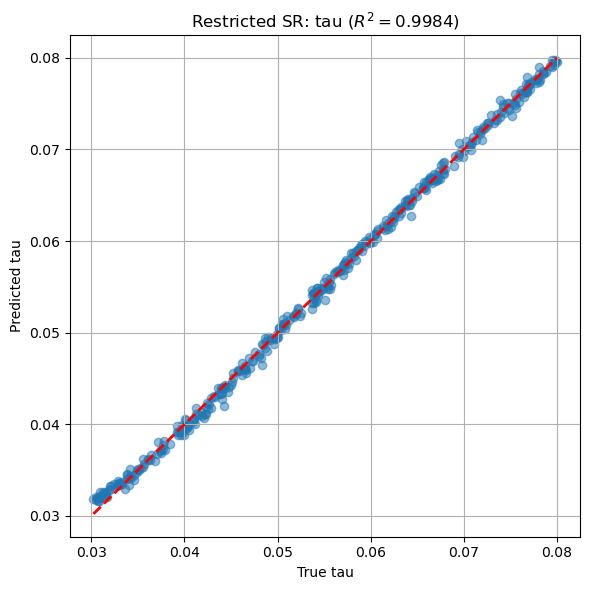

In [59]:
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
import joblib

targets_test = {
    "n_s": y_test_ns,
    "log_As": y_test_log_As,
    "omega_cdm": y_test_omega_cdm,
    "tau": y_test_tau,
}

for param in ["n_s", "log_As", "omega_cdm", "tau"]:
    model = joblib.load(f"pysr_restricted_model_{param}.pkl")
    y_true = targets_test[param]
    y_pred = model.predict(X_test_scaled)

    r2 = r2_score(y_true, y_pred)

    plt.figure(figsize=(6, 6))
    plt.scatter(y_true, y_pred, alpha=0.5)

    min_val = min(y_true.min(), y_pred.min())
    max_val = max(y_true.max(), y_pred.max())

    plt.plot([min_val, max_val], [min_val, max_val], "r--", lw=2)

    plt.xlabel(f"True {param}")
    plt.ylabel(f"Predicted {param}")
    plt.title(f"Restricted SR: {param} ($R^2={r2:.4f}$)")
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(f"figures/{param}_pred_vs_true.png", dpi=300, bbox_inches="tight")
    plt.show()

In [51]:
import pandas as pd
import joblib
from sklearn.metrics import r2_score, mean_absolute_error

summary_rows = []

# Restricted SR models
restricted_targets = {
    "n_s": y_test_ns,
    "log_As": y_test_log_As,
    "omega_cdm": y_test_omega_cdm,
    "tau": y_test_tau,
}

for param, y_true in restricted_targets.items():
    model = joblib.load(f"pysr_restricted_model_{param}.pkl")
    y_pred = model.predict(X_test_scaled)

    summary_rows.append({
        "parameter": param,
        "method": "Restricted SR",
        "R2": r2_score(y_true, y_pred),
        "MAE": mean_absolute_error(y_true, y_pred),
    })

# Full SR models
full_targets = {
    "n_s": y_test_ns,
    "log_As": y_test_log_As,
    "omega_b": y_test_omega_b,
    "omega_cdm": y_test_omega_cdm,
    "tau": y_test_tau,
}

for param, y_true in full_targets.items():
    model = joblib.load(f"pysr_full_model_{param}.pkl")
    y_pred = model.predict(X_test_scaled)

    summary_rows.append({
        "parameter": param,
        "method": "Full SR",
        "R2": r2_score(y_true, y_pred),
        "MAE": mean_absolute_error(y_true, y_pred),
    })

# Engineered omega_b
model_ob = joblib.load("pysr_restricted_model_omega_b_engineered.pkl")
y_pred_ob = model_ob.predict(Xb_test_scaled)

summary_rows.append({
    "parameter": "omega_b",
    "method": "Engineered SR",
    "R2": r2_score(yb_test, y_pred_ob),
    "MAE": mean_absolute_error(yb_test, y_pred_ob),
})

summary_df = pd.DataFrame(summary_rows)
print(summary_df)
summary_df.to_csv("final_symbolic_regression_summary.csv", index=False)

   parameter         method        R2       MAE
0        n_s  Restricted SR  0.997668  0.000654
1     log_As  Restricted SR  0.998938  0.002268
2  omega_cdm  Restricted SR  0.995267  0.000440
3        tau  Restricted SR  0.998365  0.000458
4        n_s        Full SR  0.997096  0.000715
5     log_As        Full SR  0.999452  0.001509
6    omega_b        Full SR  0.610651  0.000603
7  omega_cdm        Full SR  0.994547  0.000502
8        tau        Full SR  0.995525  0.000760
9    omega_b  Engineered SR  0.801570  0.000437


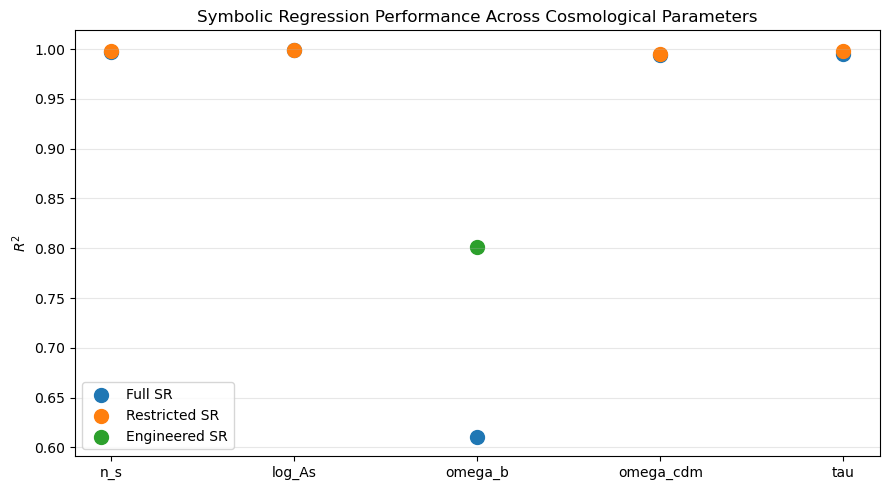

In [61]:
import matplotlib.pyplot as plt

params = ["n_s", "log_As", "omega_b", "omega_cdm", "tau"]
methods = ["Full SR", "Restricted SR", "Engineered SR"]

plt.figure(figsize=(9, 5))

for method in methods:
    sub = summary_df[summary_df["method"] == method]
    x = [params.index(p) for p in sub["parameter"]]
    y = sub["R2"].values
    plt.scatter(x, y, s=100, label=method)

plt.xticks(range(len(params)), params)
plt.ylabel(r"$R^2$")
plt.title(r"Symbolic Regression Performance Across Cosmological Parameters")
plt.grid(True, axis="y", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig("figures/sr_r2_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

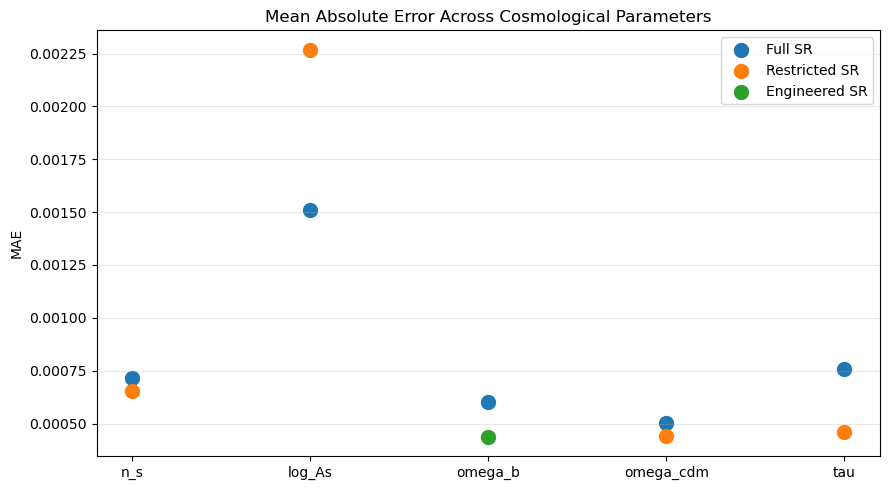

In [63]:
plt.figure(figsize=(9, 5))

for method in methods:
    sub = summary_df[summary_df["method"] == method]
    x = [params.index(p) for p in sub["parameter"]]
    y = sub["MAE"].values
    plt.scatter(x, y, s=100, label=method)

plt.xticks(range(len(params)), params)
plt.ylabel("MAE")
plt.title("Mean Absolute Error Across Cosmological Parameters")
plt.grid(True, axis="y", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig("figures/sr_mae_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

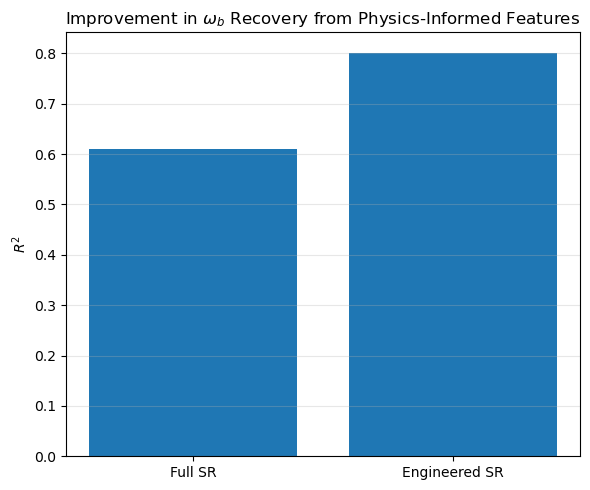

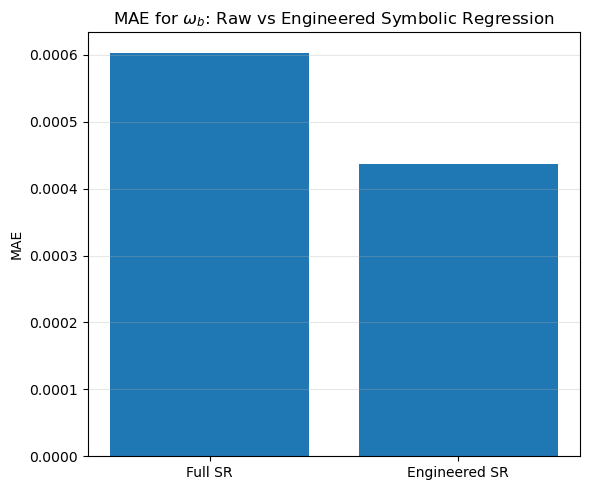

In [65]:
omega_b_methods = ["Full SR", "Engineered SR"]
omega_b_df = summary_df[
    (summary_df["parameter"] == "omega_b") &
    (summary_df["method"].isin(omega_b_methods))
]

plt.figure(figsize=(6, 5))
plt.bar(omega_b_df["method"], omega_b_df["R2"])
plt.ylabel(r"$R^2$")
plt.title(r"Improvement in $\omega_b$ Recovery from Physics-Informed Features")
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("figures/omega_b_improvement_r2.png", dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(6, 5))
plt.bar(omega_b_df["method"], omega_b_df["MAE"])
plt.ylabel("MAE")
plt.title(r"MAE for $\omega_b$: Raw vs Engineered Symbolic Regression")
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("figures/omega_b_improvement_mae.png", dpi=300, bbox_inches="tight")
plt.show()

In [72]:
# Recreate target dictionaries (same split used in SR)

targets_train = {
    "n_s": y_train_ns,
    "log_As": y_train_log_As,
    "omega_b": y_train_omega_b,
    "omega_cdm": y_train_omega_cdm,
    "tau": y_train_tau,
}

targets_test = {
    "n_s": y_test_ns,
    "log_As": y_test_log_As,
    "omega_b": y_test_omega_b,
    "omega_cdm": y_test_omega_cdm,
    "tau": y_test_tau,
}

In [73]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error
import pandas as pd

rf_results = []

for name in targets_train.keys():
    y_train = targets_train[name]
    y_test = targets_test[name]

    rf = RandomForestRegressor(
        n_estimators=500,
        max_depth=None,
        n_jobs=-1,
        random_state=42,
    )

    rf.fit(X_train_scaled, y_train)
    y_pred = rf.predict(X_test_scaled)

    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)

    rf_results.append({
        "parameter": name,
        "method": "Random Forest",
        "R2": r2,
        "MAE": mae
    })

    print(f"{name:10s}  RF R2 = {r2:.4f}   RF MAE = {mae:.6f}")

rf_results_df = pd.DataFrame(rf_results)
rf_results_df.to_csv("rf_baseline_results.csv", index=False)

n_s         RF R2 = 0.9683   RF MAE = 0.002510
log_As      RF R2 = 0.9957   RF MAE = 0.004351
omega_b     RF R2 = 0.9981   RF MAE = 0.000037
omega_cdm   RF R2 = 0.9991   RF MAE = 0.000196
tau         RF R2 = 0.9965   RF MAE = 0.000669


# PRD-Optimized Figures

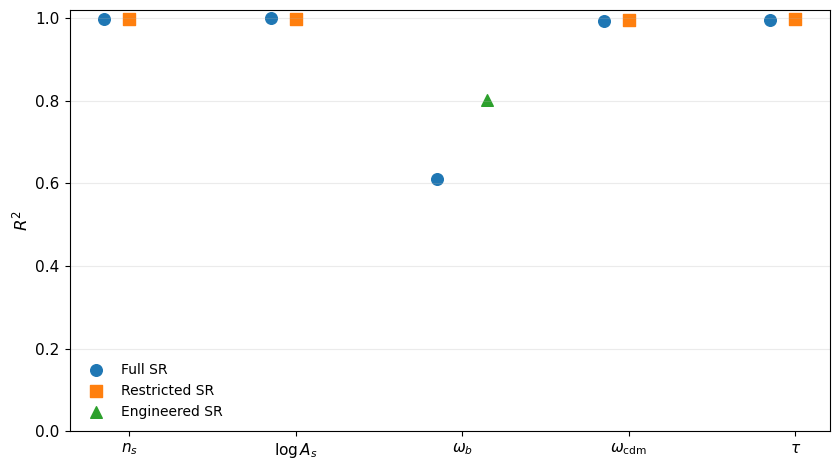

In [74]:
import matplotlib.pyplot as plt
import numpy as np

params = [r"$n_s$", r"$\log A_s$", r"$\omega_b$", r"$\omega_{\rm cdm}$", r"$\tau$"]
param_keys = ["n_s", "log_As", "omega_b", "omega_cdm", "tau"]

methods = ["Full SR", "Restricted SR", "Engineered SR"]
markers = ["o", "s", "^"]
offsets = [-0.15, 0.0, 0.15]

x_base = np.arange(len(param_keys))

plt.figure(figsize=(8.5, 4.8))

for method, marker, dx in zip(methods, markers, offsets):
    sub = summary_df[summary_df["method"] == method]
    y = [sub[sub["parameter"] == p]["R2"].values[0] if p in sub["parameter"].values else np.nan
         for p in param_keys]
    plt.scatter(x_base + dx, y, s=70, marker=marker, label=method)

plt.xticks(x_base, params, fontsize=11)
plt.yticks(fontsize=11)
plt.ylabel(r"$R^2$", fontsize=12)
plt.ylim(0, 1.02)
plt.grid(True, axis="y", alpha=0.25)
plt.legend(frameon=False, fontsize=10)
plt.tight_layout()

plt.savefig("figures/sr_r2_comparison.pdf", bbox_inches="tight")
plt.savefig("figures/sr_r2_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

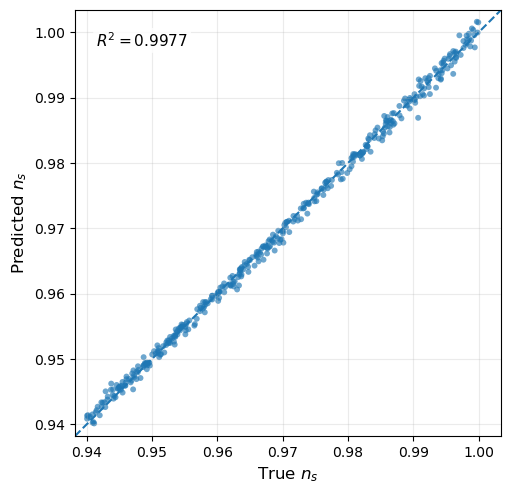

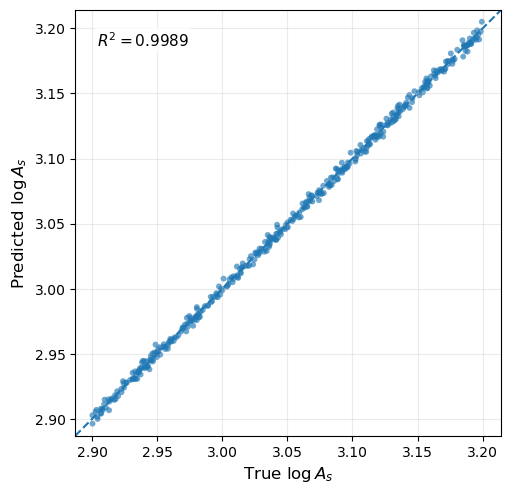

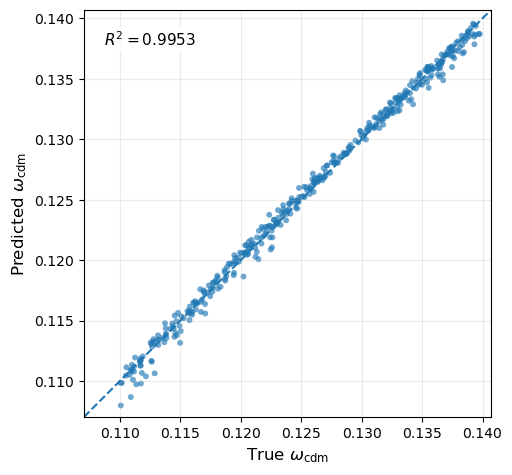

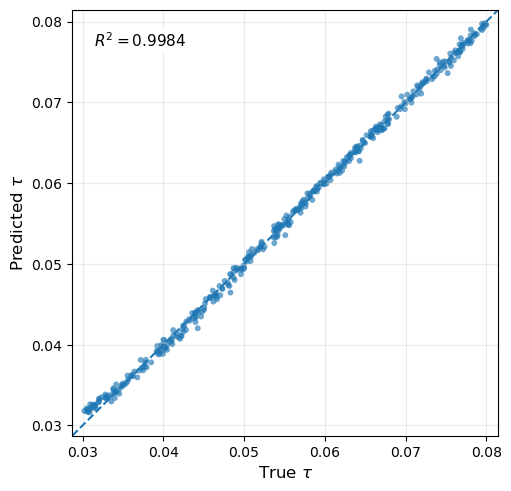

In [75]:
import os
import joblib
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

os.makedirs("figures", exist_ok=True)

targets_test = {
    "n_s": y_test_ns,
    "log_As": y_test_log_As,
    "omega_cdm": y_test_omega_cdm,
    "tau": y_test_tau,
}

label_map = {
    "n_s": r"$n_s$",
    "log_As": r"$\log A_s$",
    "omega_cdm": r"$\omega_{\rm cdm}$",
    "tau": r"$\tau$",
}

for param in ["n_s", "log_As", "omega_cdm", "tau"]:
    model = joblib.load(f"pysr_restricted_model_{param}.pkl")
    y_true = np.asarray(targets_test[param])
    y_pred = np.asarray(model.predict(X_test_scaled))

    r2 = r2_score(y_true, y_pred)

    # Common plotting range for honest comparison
    min_val = min(y_true.min(), y_pred.min())
    max_val = max(y_true.max(), y_pred.max())
    pad = 0.03 * (max_val - min_val) if max_val > min_val else 1e-6
    lo, hi = min_val - pad, max_val + pad

    fig, ax = plt.subplots(figsize=(5.2, 5.2))

    ax.scatter(
        y_true,
        y_pred,
        s=18,
        alpha=0.65,
        edgecolors="none"
    )

    # 1:1 reference line
    ax.plot([lo, hi], [lo, hi], "--", lw=1.5)

    ax.set_xlim(lo, hi)
    ax.set_ylim(lo, hi)
    ax.set_aspect("equal", adjustable="box")

    ax.set_xlabel(f"True {label_map[param]}", fontsize=12)
    ax.set_ylabel(f"Predicted {label_map[param]}", fontsize=12)

    ax.tick_params(axis="both", labelsize=10)
    ax.grid(True, alpha=0.25)

    # In-panel metric annotation instead of title
    ax.text(
        0.05, 0.95,
        rf"$R^2 = {r2:.4f}$",
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=11,
        bbox=dict(boxstyle="round,pad=0.2", facecolor="white", alpha=0.85, edgecolor="none")
    )

    fig.tight_layout()

    fig.savefig(f"figures/restricted_{param}_pred_vs_true.pdf", bbox_inches="tight")
    fig.savefig(f"figures/restricted_{param}_pred_vs_true.png", dpi=300, bbox_inches="tight")
    plt.show()

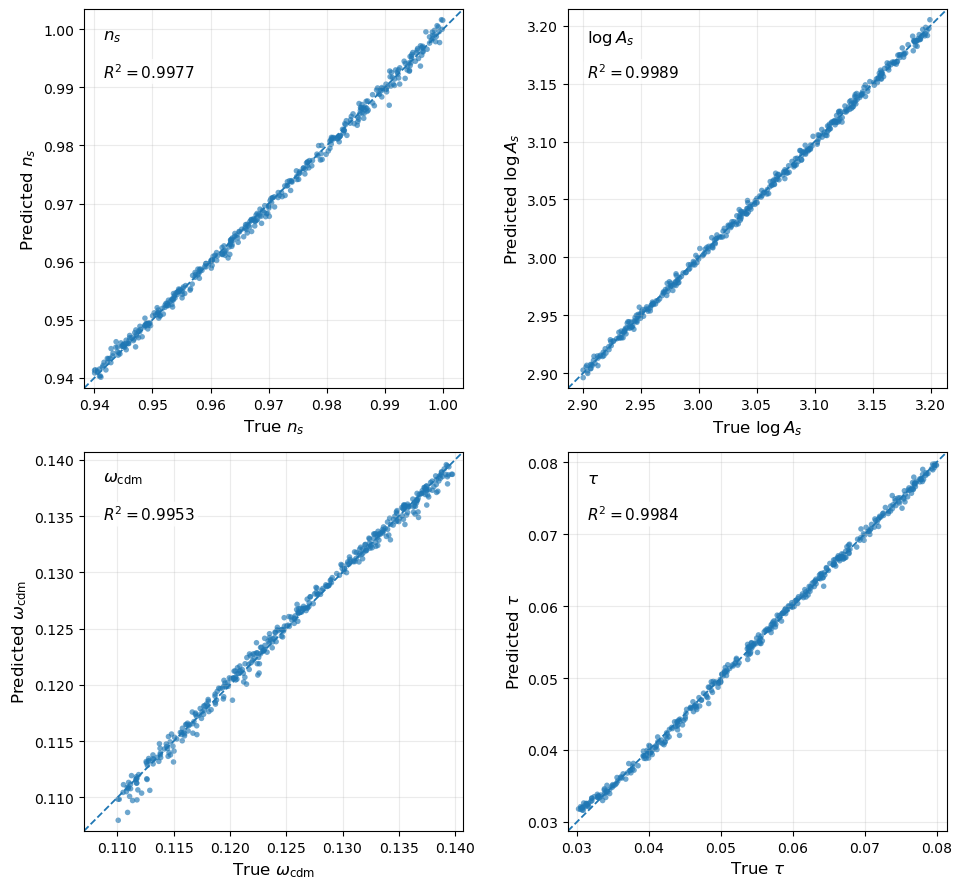

In [76]:
import os
import joblib
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

os.makedirs("figures", exist_ok=True)

targets_test = {
    "n_s": y_test_ns,
    "log_As": y_test_log_As,
    "omega_cdm": y_test_omega_cdm,
    "tau": y_test_tau,
}

label_map = {
    "n_s": r"$n_s$",
    "log_As": r"$\log A_s$",
    "omega_cdm": r"$\omega_{\rm cdm}$",
    "tau": r"$\tau$",
}

param_order = ["n_s", "log_As", "omega_cdm", "tau"]

fig, axes = plt.subplots(2, 2, figsize=(10, 9))
axes = axes.flatten()

for ax, param in zip(axes, param_order):
    model = joblib.load(f"pysr_restricted_model_{param}.pkl")
    y_true = np.asarray(targets_test[param])
    y_pred = np.asarray(model.predict(X_test_scaled))

    r2 = r2_score(y_true, y_pred)

    min_val = min(y_true.min(), y_pred.min())
    max_val = max(y_true.max(), y_pred.max())
    span = max_val - min_val
    pad = 0.03 * span if span > 0 else 1e-6
    lo, hi = min_val - pad, max_val + pad

    ax.scatter(
        y_true,
        y_pred,
        s=16,
        alpha=0.65,
        edgecolors="none"
    )

    # 1:1 reference line
    ax.plot([lo, hi], [lo, hi], "--", lw=1.3)

    ax.set_xlim(lo, hi)
    ax.set_ylim(lo, hi)
    ax.set_aspect("equal", adjustable="box")

    ax.set_xlabel(f"True {label_map[param]}", fontsize=12)
    ax.set_ylabel(f"Predicted {label_map[param]}", fontsize=12)
    ax.tick_params(axis="both", labelsize=10)
    ax.grid(True, alpha=0.25)

    # Panel label and R^2 annotation
    ax.text(
        0.05, 0.95,
        label_map[param],
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=12
    )

    ax.text(
        0.05, 0.86,
        rf"$R^2 = {r2:.4f}$",
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=11,
        bbox=dict(
            boxstyle="round,pad=0.2",
            facecolor="white",
            alpha=0.85,
            edgecolor="none"
        )
    )

fig.tight_layout()
fig.savefig("figures/restricted_sr_pred_vs_true_2x2.pdf", bbox_inches="tight")
fig.savefig("figures/restricted_sr_pred_vs_true_2x2.png", dpi=300, bbox_inches="tight")
plt.show()

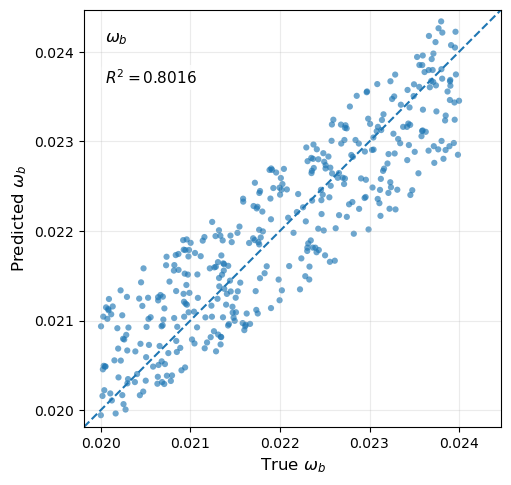

In [77]:
import numpy as np
import matplotlib.pyplot as plt

y_true = np.asarray(yb_test)
y_pred = np.asarray(yhat_test_best)

r2 = 0.8016  # or compute dynamically if needed

# Define common axis limits
min_val = min(y_true.min(), y_pred.min())
max_val = max(y_true.max(), y_pred.max())
span = max_val - min_val
pad = 0.03 * span if span > 0 else 1e-6
lo, hi = min_val - pad, max_val + pad

fig, ax = plt.subplots(figsize=(5.2, 5.2))

ax.scatter(
    y_true,
    y_pred,
    s=20,
    alpha=0.65,
    edgecolors="none"
)

# 1:1 reference line (neutral style)
ax.plot([lo, hi], [lo, hi], "--", lw=1.5)

ax.set_xlim(lo, hi)
ax.set_ylim(lo, hi)
ax.set_aspect("equal", adjustable="box")

ax.set_xlabel(r"True $\omega_b$", fontsize=12)
ax.set_ylabel(r"Predicted $\omega_b$", fontsize=12)

ax.tick_params(axis="both", labelsize=10)
ax.grid(True, alpha=0.25)

# In-panel annotation
ax.text(
    0.05, 0.95,
    r"$\omega_b$",
    transform=ax.transAxes,
    ha="left",
    va="top",
    fontsize=12
)

ax.text(
    0.05, 0.86,
    rf"$R^2 = {r2:.4f}$",
    transform=ax.transAxes,
    ha="left",
    va="top",
    fontsize=11,
    bbox=dict(
        boxstyle="round,pad=0.2",
        facecolor="white",
        alpha=0.85,
        edgecolor="none"
    )
)

fig.tight_layout()

fig.savefig("figures/omega_b_engineered_pred_vs_true.pdf", bbox_inches="tight")
fig.savefig("figures/omega_b_engineered_pred_vs_true.png", dpi=300, bbox_inches="tight")

plt.show()

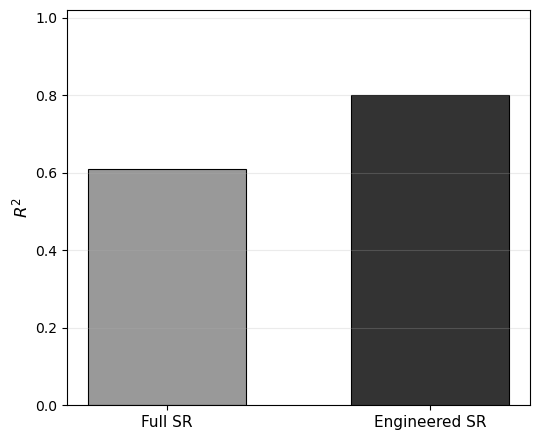

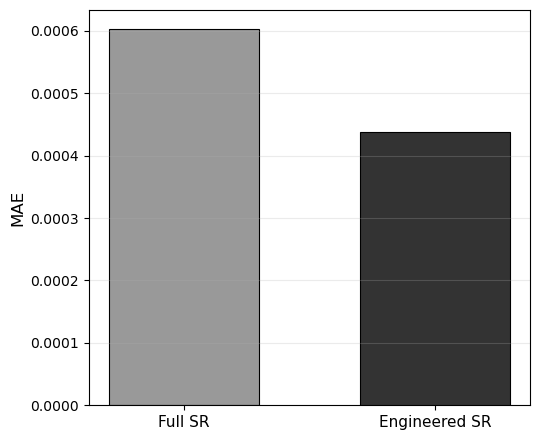

In [78]:
import os
import numpy as np
import matplotlib.pyplot as plt

os.makedirs("figures", exist_ok=True)

# Ensure consistent ordering
method_order = ["Full SR", "Engineered SR"]
omega_b_df = summary_df[
    (summary_df["parameter"] == "omega_b") &
    (summary_df["method"].isin(method_order))
].set_index("method").loc[method_order]

methods = omega_b_df.index.tolist()
x = np.arange(len(methods))

# Use grayscale-friendly styling
colors = ["0.6", "0.2"]  # light gray, dark gray

# -----------------------------
# R^2 plot
# -----------------------------
fig, ax = plt.subplots(figsize=(5.5, 4.5))

ax.bar(
    x,
    omega_b_df["R2"].values,
    width=0.6,
    color=colors,
    edgecolor="black",
    linewidth=0.8
)

ax.set_xticks(x)
ax.set_xticklabels(methods, fontsize=11)
ax.set_ylabel(r"$R^2$", fontsize=12)

ax.tick_params(axis="y", labelsize=10)
ax.grid(True, axis="y", alpha=0.25)

# Optional: controlled y-range
ax.set_ylim(0, 1.02)

fig.tight_layout()

fig.savefig("figures/omega_b_improvement_r2.pdf", bbox_inches="tight")
fig.savefig("figures/omega_b_improvement_r2.png", dpi=300, bbox_inches="tight")

plt.show()


# -----------------------------
# MAE plot
# -----------------------------
fig, ax = plt.subplots(figsize=(5.5, 4.5))

ax.bar(
    x,
    omega_b_df["MAE"].values,
    width=0.6,
    color=colors,
    edgecolor="black",
    linewidth=0.8
)

ax.set_xticks(x)
ax.set_xticklabels(methods, fontsize=11)
ax.set_ylabel(r"MAE", fontsize=12)

ax.tick_params(axis="y", labelsize=10)
ax.grid(True, axis="y", alpha=0.25)

fig.tight_layout()

fig.savefig("figures/omega_b_improvement_mae.pdf", bbox_inches="tight")
fig.savefig("figures/omega_b_improvement_mae.png", dpi=300, bbox_inches="tight")

plt.show()

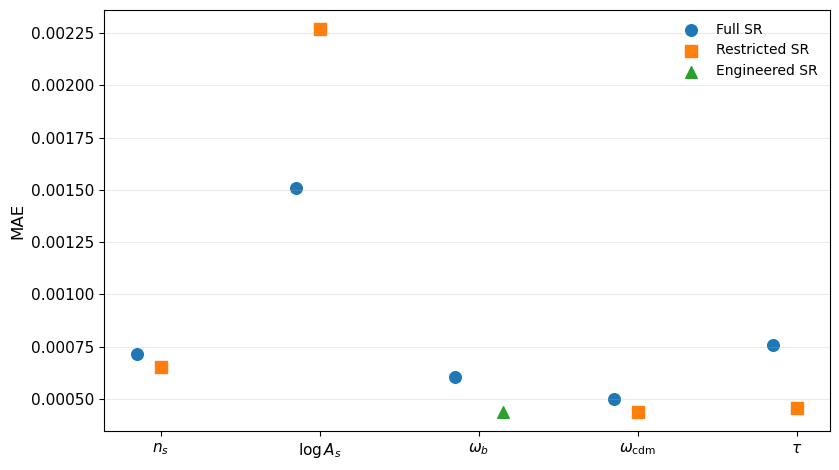

In [79]:
import numpy as np
import matplotlib.pyplot as plt

params = [r"$n_s$", r"$\log A_s$", r"$\omega_b$", r"$\omega_{\rm cdm}$", r"$\tau$"]
param_keys = ["n_s", "log_As", "omega_b", "omega_cdm", "tau"]

methods = ["Full SR", "Restricted SR", "Engineered SR"]
markers = ["o", "s", "^"]
offsets = [-0.15, 0.0, 0.15]

x_base = np.arange(len(param_keys))

plt.figure(figsize=(8.5, 4.8))

for method, marker, dx in zip(methods, markers, offsets):
    sub = summary_df[summary_df["method"] == method]

    y = [
        sub[sub["parameter"] == p]["MAE"].values[0]
        if p in sub["parameter"].values else np.nan
        for p in param_keys
    ]

    plt.scatter(
        x_base + dx,
        y,
        s=70,
        marker=marker,
        label=method
    )

plt.xticks(x_base, params, fontsize=11)
plt.yticks(fontsize=11)
plt.ylabel(r"MAE", fontsize=12)

plt.grid(True, axis="y", alpha=0.25)
plt.legend(frameon=False, fontsize=10)

plt.tight_layout()

plt.savefig("figures/sr_mae_comparison.pdf", bbox_inches="tight")
plt.savefig("figures/sr_mae_comparison.png", dpi=300, bbox_inches="tight")

plt.show()

# JCAP-optimized Figures

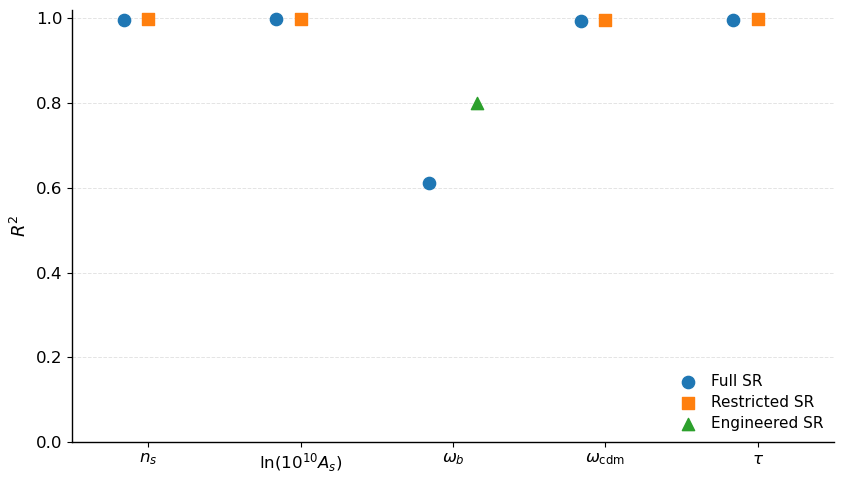

In [91]:
import matplotlib.pyplot as plt
import numpy as np

# Parameters and plotting order
params = [
    r"$n_s$",
    r"$\ln(10^{10} A_s)$",
    r"$\omega_b$",
    r"$\omega_{\mathrm{cdm}}$",
    r"$\tau$"
]
param_keys = ["n_s", "log_As", "omega_b", "omega_cdm", "tau"]

methods = ["Full SR", "Restricted SR", "Engineered SR"]
markers = ["o", "s", "^"]
offsets = [-0.16, 0.0, 0.16]

x_base = np.arange(len(param_keys))

# Global style tuning for publication
plt.rcParams.update({
    "font.size": 12,
    "axes.labelsize": 13,
    "axes.titlesize": 13,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 11,
    "lines.linewidth": 1.2,
    "axes.linewidth": 1.0,
    "pdf.fonttype": 42,
    "ps.fonttype": 42
})

fig, ax = plt.subplots(figsize=(8.6, 5.0))

for method, marker, dx in zip(methods, markers, offsets):
    sub = summary_df[summary_df["method"] == method]
    y = [
        sub.loc[sub["parameter"] == p, "R2"].values[0]
        if p in sub["parameter"].values else np.nan
        for p in param_keys
    ]
    ax.scatter(
        x_base + dx,
        y,
        s=78,
        marker=marker,
        label=method,
        zorder=3
    )

# Axes and labels
ax.set_xticks(x_base)
ax.set_xticklabels(params)
ax.set_ylabel(r"$R^2$")
ax.set_ylim(0, 1.02)
ax.set_xlim(-0.5, len(param_keys) - 0.5)

# Grid and spines
ax.grid(True, axis="y", linestyle="--", linewidth=0.7, alpha=0.35, zorder=0)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Legend
ax.legend(
    loc="lower right",
    frameon=False,
    handletextpad=0.5,
    borderpad=0.2,
    labelspacing=0.4
)

fig.tight_layout()

# Save outputs
fig.savefig("figures/sr_r2_comparison.pdf", bbox_inches="tight")
fig.savefig("figures/sr_r2_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

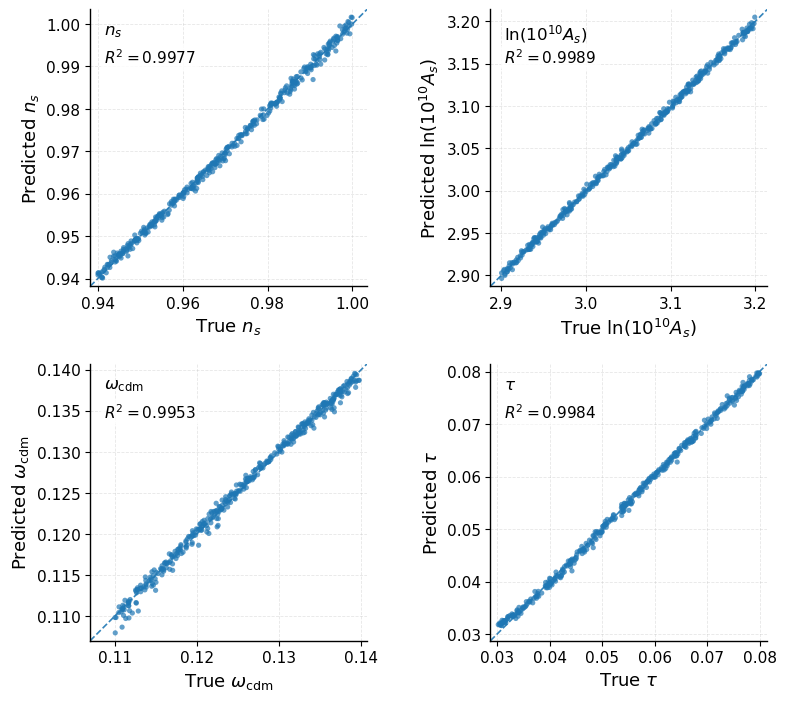

In [82]:
import os
import joblib
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

os.makedirs("figures", exist_ok=True)

# Publication-style matplotlib settings
plt.rcParams.update({
    "font.size": 12,
    "axes.labelsize": 13,
    "axes.titlesize": 13,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 11,
    "axes.linewidth": 1.0,
    "lines.linewidth": 1.2,
    "pdf.fonttype": 42,
    "ps.fonttype": 42
})

targets_test = {
    "n_s": y_test_ns,
    "log_As": y_test_log_As,
    "omega_cdm": y_test_omega_cdm,
    "tau": y_test_tau,
}

label_map = {
    "n_s": r"$n_s$",
    "log_As": r"$\ln(10^{10} A_s)$",
    "omega_cdm": r"$\omega_{\mathrm{cdm}}$",
    "tau": r"$\tau$",
}

param_order = ["n_s", "log_As", "omega_cdm", "tau"]

fig, axes = plt.subplots(2, 2, figsize=(9.2, 8.2))
axes = axes.flatten()

for ax, param in zip(axes, param_order):
    model = joblib.load(f"pysr_restricted_model_{param}.pkl")
    y_true = np.asarray(targets_test[param])
    y_pred = np.asarray(model.predict(X_test_scaled))

    r2 = r2_score(y_true, y_pred)

    min_val = min(y_true.min(), y_pred.min())
    max_val = max(y_true.max(), y_pred.max())
    span = max_val - min_val
    pad = 0.03 * span if span > 0 else 1e-6
    lo, hi = min_val - pad, max_val + pad

    # Scatter points
    ax.scatter(
        y_true,
        y_pred,
        s=14,
        alpha=0.70,
        edgecolors="none",
        zorder=3
    )

    # 1:1 reference line
    ax.plot(
        [lo, hi],
        [lo, hi],
        "--",
        lw=1.2,
        alpha=0.9,
        zorder=2
    )

    # Limits and aspect
    ax.set_xlim(lo, hi)
    ax.set_ylim(lo, hi)
    ax.set_aspect("equal", adjustable="box")

    # Labels
    ax.set_xlabel(f"True {label_map[param]}")
    ax.set_ylabel(f"Predicted {label_map[param]}")

    # Grid and spines
    ax.grid(True, linestyle="--", linewidth=0.6, alpha=0.30, zorder=0)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    # Panel parameter label
    ax.text(
        0.05, 0.95,
        label_map[param],
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=12
    )

    # R^2 annotation
    ax.text(
        0.05, 0.86,
        rf"$R^2 = {r2:.4f}$",
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=11,
        bbox=dict(
            boxstyle="round,pad=0.22",
            facecolor="white",
            alpha=0.85,
            edgecolor="none"
        )
    )

# Improve spacing between panels
fig.subplots_adjust(wspace=0.28, hspace=0.28)

# Save
fig.savefig("figures/restricted_sr_pred_vs_true_2x2.pdf", bbox_inches="tight")
fig.savefig("figures/restricted_sr_pred_vs_true_2x2.png", dpi=300, bbox_inches="tight")
plt.show()

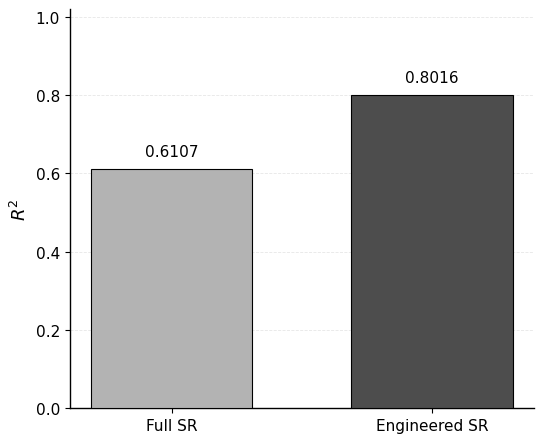

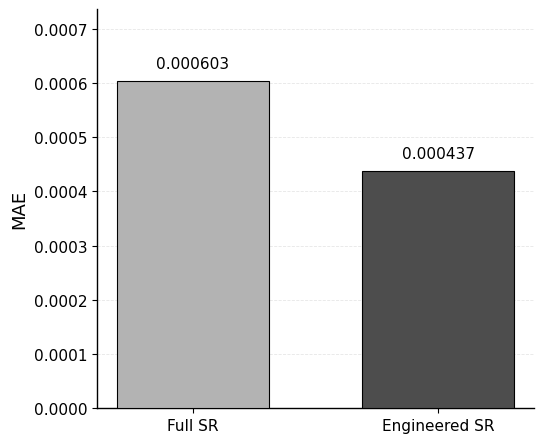

In [83]:
import os
import numpy as np
import matplotlib.pyplot as plt

os.makedirs("figures", exist_ok=True)

# Publication-style matplotlib settings
plt.rcParams.update({
    "font.size": 12,
    "axes.labelsize": 13,
    "axes.titlesize": 13,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 11,
    "axes.linewidth": 1.0,
    "lines.linewidth": 1.2,
    "pdf.fonttype": 42,
    "ps.fonttype": 42
})

# Ensure consistent ordering
method_order = ["Full SR", "Engineered SR"]
omega_b_df = summary_df[
    (summary_df["parameter"] == "omega_b") &
    (summary_df["method"].isin(method_order))
].set_index("method").loc[method_order]

methods = omega_b_df.index.tolist()
x = np.arange(len(methods))

# Grayscale-friendly styling
colors = ["0.70", "0.30"]  # light gray, dark gray
bar_width = 0.62

# -----------------------------
# Figure 3: R^2 plot
# -----------------------------
fig, ax = plt.subplots(figsize=(5.6, 4.6))

bars = ax.bar(
    x,
    omega_b_df["R2"].values,
    width=bar_width,
    color=colors,
    edgecolor="black",
    linewidth=0.8,
    zorder=3
)

ax.set_xticks(x)
ax.set_xticklabels(methods)
ax.set_ylabel(r"$R^2$")
ax.set_ylim(0, 1.02)

ax.grid(True, axis="y", linestyle="--", linewidth=0.6, alpha=0.30, zorder=0)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Numeric annotations
for bar, val in zip(bars, omega_b_df["R2"].values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        val + 0.025,
        f"{val:.4f}",
        ha="center",
        va="bottom",
        fontsize=11
    )

fig.tight_layout()
fig.savefig("figures/omega_b_improvement_r2.pdf", bbox_inches="tight")
fig.savefig("figures/omega_b_improvement_r2.png", dpi=300, bbox_inches="tight")
plt.show()


# -----------------------------
# Figure 6: MAE plot
# -----------------------------
fig, ax = plt.subplots(figsize=(5.6, 4.6))

bars = ax.bar(
    x,
    omega_b_df["MAE"].values,
    width=bar_width,
    color=colors,
    edgecolor="black",
    linewidth=0.8,
    zorder=3
)

ax.set_xticks(x)
ax.set_xticklabels(methods)
ax.set_ylabel("MAE")

ax.grid(True, axis="y", linestyle="--", linewidth=0.6, alpha=0.30, zorder=0)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Add a little headroom for text
ymax = omega_b_df["MAE"].max()
ax.set_ylim(0, ymax * 1.22)

# Numeric annotations
for bar, val in zip(bars, omega_b_df["MAE"].values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        val + ymax * 0.03,
        f"{val:.6f}",
        ha="center",
        va="bottom",
        fontsize=11
    )

fig.tight_layout()
fig.savefig("figures/omega_b_improvement_mae.pdf", bbox_inches="tight")
fig.savefig("figures/omega_b_improvement_mae.png", dpi=300, bbox_inches="tight")
plt.show()

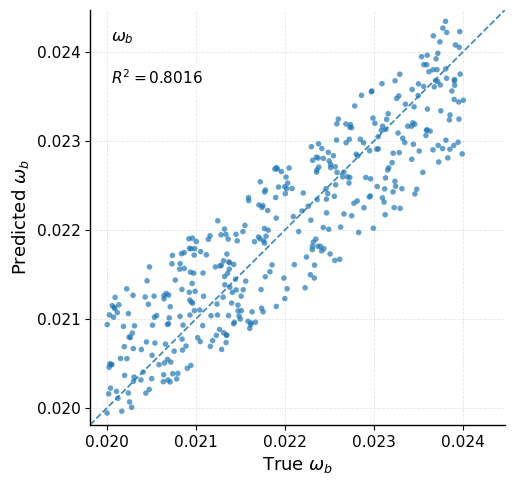

In [84]:
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

os.makedirs("figures", exist_ok=True)

# Publication-style matplotlib settings
plt.rcParams.update({
    "font.size": 12,
    "axes.labelsize": 13,
    "axes.titlesize": 13,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 11,
    "axes.linewidth": 1.0,
    "lines.linewidth": 1.2,
    "pdf.fonttype": 42,
    "ps.fonttype": 42
})

y_true = np.asarray(yb_test)
y_pred = np.asarray(yhat_test_best)

# Compute R^2 directly to avoid hard-coded mismatch
r2 = r2_score(y_true, y_pred)

# Common axis limits with padding
min_val = min(y_true.min(), y_pred.min())
max_val = max(y_true.max(), y_pred.max())
span = max_val - min_val
pad = 0.03 * span if span > 0 else 1e-6
lo, hi = min_val - pad, max_val + pad

fig, ax = plt.subplots(figsize=(5.3, 5.3))

# Scatter points
ax.scatter(
    y_true,
    y_pred,
    s=16,
    alpha=0.70,
    edgecolors="none",
    zorder=3
)

# 1:1 reference line
ax.plot(
    [lo, hi],
    [lo, hi],
    "--",
    lw=1.2,
    alpha=0.9,
    zorder=2
)

# Limits and aspect
ax.set_xlim(lo, hi)
ax.set_ylim(lo, hi)
ax.set_aspect("equal", adjustable="box")

# Labels
ax.set_xlabel(r"True $\omega_b$")
ax.set_ylabel(r"Predicted $\omega_b$")

# Grid and spines
ax.grid(True, linestyle="--", linewidth=0.6, alpha=0.30, zorder=0)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# In-panel parameter label
ax.text(
    0.05, 0.95,
    r"$\omega_b$",
    transform=ax.transAxes,
    ha="left",
    va="top",
    fontsize=12
)

# R^2 annotation
ax.text(
    0.05, 0.86,
    rf"$R^2 = {r2:.4f}$",
    transform=ax.transAxes,
    ha="left",
    va="top",
    fontsize=11,
    bbox=dict(
        boxstyle="round,pad=0.22",
        facecolor="white",
        alpha=0.85,
        edgecolor="none"
    )
)

fig.tight_layout()

fig.savefig("figures/omega_b_engineered_pred_vs_true.pdf", bbox_inches="tight")
fig.savefig("figures/omega_b_engineered_pred_vs_true.png", dpi=300, bbox_inches="tight")
plt.show()

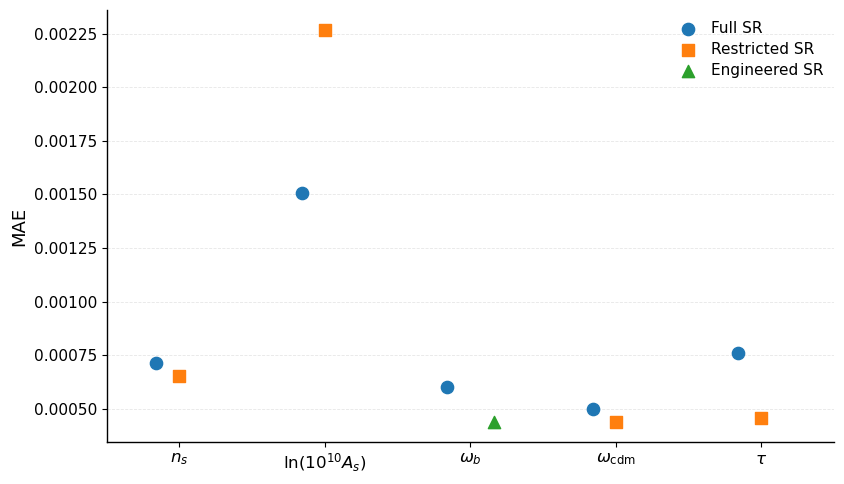

In [92]:
import os
import numpy as np
import matplotlib.pyplot as plt

os.makedirs("figures", exist_ok=True)

# Parameter labels and order
params = [
    r"$n_s$",
    r"$\ln(10^{10} A_s)$",
    r"$\omega_b$",
    r"$\omega_{\mathrm{cdm}}$",
    r"$\tau$"
]
param_keys = ["n_s", "log_As", "omega_b", "omega_cdm", "tau"]

methods = ["Full SR", "Restricted SR", "Engineered SR"]
markers = ["o", "s", "^"]
offsets = [-0.16, 0.0, 0.16]

x_base = np.arange(len(param_keys))

# Publication-style settings
plt.rcParams.update({
    "font.size": 12,
    "axes.labelsize": 13,
    "axes.titlesize": 13,
    "xtick.labelsize": 12,
    "ytick.labelsize": 11,
    "legend.fontsize": 11,
    "axes.linewidth": 1.0,
    "lines.linewidth": 1.2,
    "pdf.fonttype": 42,
    "ps.fonttype": 42
})

fig, ax = plt.subplots(figsize=(8.6, 5.0))

for method, marker, dx in zip(methods, markers, offsets):
    sub = summary_df[summary_df["method"] == method]

    y = [
        sub.loc[sub["parameter"] == p, "MAE"].values[0]
        if p in sub["parameter"].values else np.nan
        for p in param_keys
    ]

    ax.scatter(
        x_base + dx,
        y,
        s=78,
        marker=marker,
        label=method,
        zorder=3
    )

# Axes and labels
ax.set_xticks(x_base)
ax.set_xticklabels(params)
ax.set_ylabel("MAE")
ax.set_xlim(-0.5, len(param_keys) - 0.5)

# Grid and spines
ax.grid(True, axis="y", linestyle="--", linewidth=0.6, alpha=0.30, zorder=0)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Legend
ax.legend(
    frameon=False,
    loc="upper right",
    handletextpad=0.5,
    borderpad=0.2,
    labelspacing=0.4
)

fig.tight_layout()

fig.savefig("figures/sr_mae_comparison.pdf", bbox_inches="tight")
fig.savefig("figures/sr_mae_comparison.png", dpi=300, bbox_inches="tight")
plt.show()